# Knowledge Graph XAI System for CFRP Composites

This notebook demonstrates the Knowledge Graph-based Explainable AI system for RUL prediction in CFRP composite materials.

## Contents:
1. Load trained models
2. Build and visualize Knowledge Graph
3. Generate explanations for predictions
4. Compare model explanations
5. Interactive exploration

In [54]:
# Import required libraries
import sys
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from pathlib import Path

# Add parent directory to path
sys.path.insert(0, os.path.abspath('..'))

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Import custom modules
from modules import CFRPKnowledgeGraph, XAIExplainer


Using device: cpu


## 1. Build Knowledge Graph

Create the domain knowledge graph for CFRP composite degradation.

In [55]:
# Build Knowledge Graph
kg = CFRPKnowledgeGraph()

# Print graph statistics
print("Knowledge Graph Statistics:")
print(f"  Nodes: {kg.graph.number_of_nodes()}")
print(f"  Edges: {kg.graph.number_of_edges()}")
print("\nNode Types:")
for node_type in ['feature', 'phenomenon', 'stage']:
    nodes = [n for n, d in kg.graph.nodes(data=True) if d.get('type') == node_type]
    print(f"  {node_type.capitalize()}s: {len(nodes)}")
    for node in nodes:
        print(f"    - {node}")

Knowledge Graph Statistics:
  Nodes: 33
  Edges: 25

Node Types:
  Features: 24
    - avg_delta_psd
    - std_delta_psd
    - avg_delta_tof
    - std_delta_tof
    - avg_scatter_energy
    - std_scatter_energy
    - avg_rms
    - avg_peak_frequency
    - n_pzt_paths
    - mean_intensity
    - std_intensity
    - image_entropy
    - mean_strain_rms
    - std_strain_rms
    - mean_strain_amplitude
    - n_active_channels
    - stiffness_degradation
    - cycles
    - normalized_cycles
    - delta_mean_intensity
    - delta_stiffness
    - delta_avg_delta_psd
    - RUL
    - normalized_RUL
  Phenomenons: 5
    - crack_propagation
    - delamination
    - matrix_cracking
    - fiber_breakage
    - stiffness_loss
  Stages: 4
    - healthy
    - early_damage
    - progressive
    - critical


## 2. Visualize Knowledge Graph

Visualize the structure of the knowledge graph.

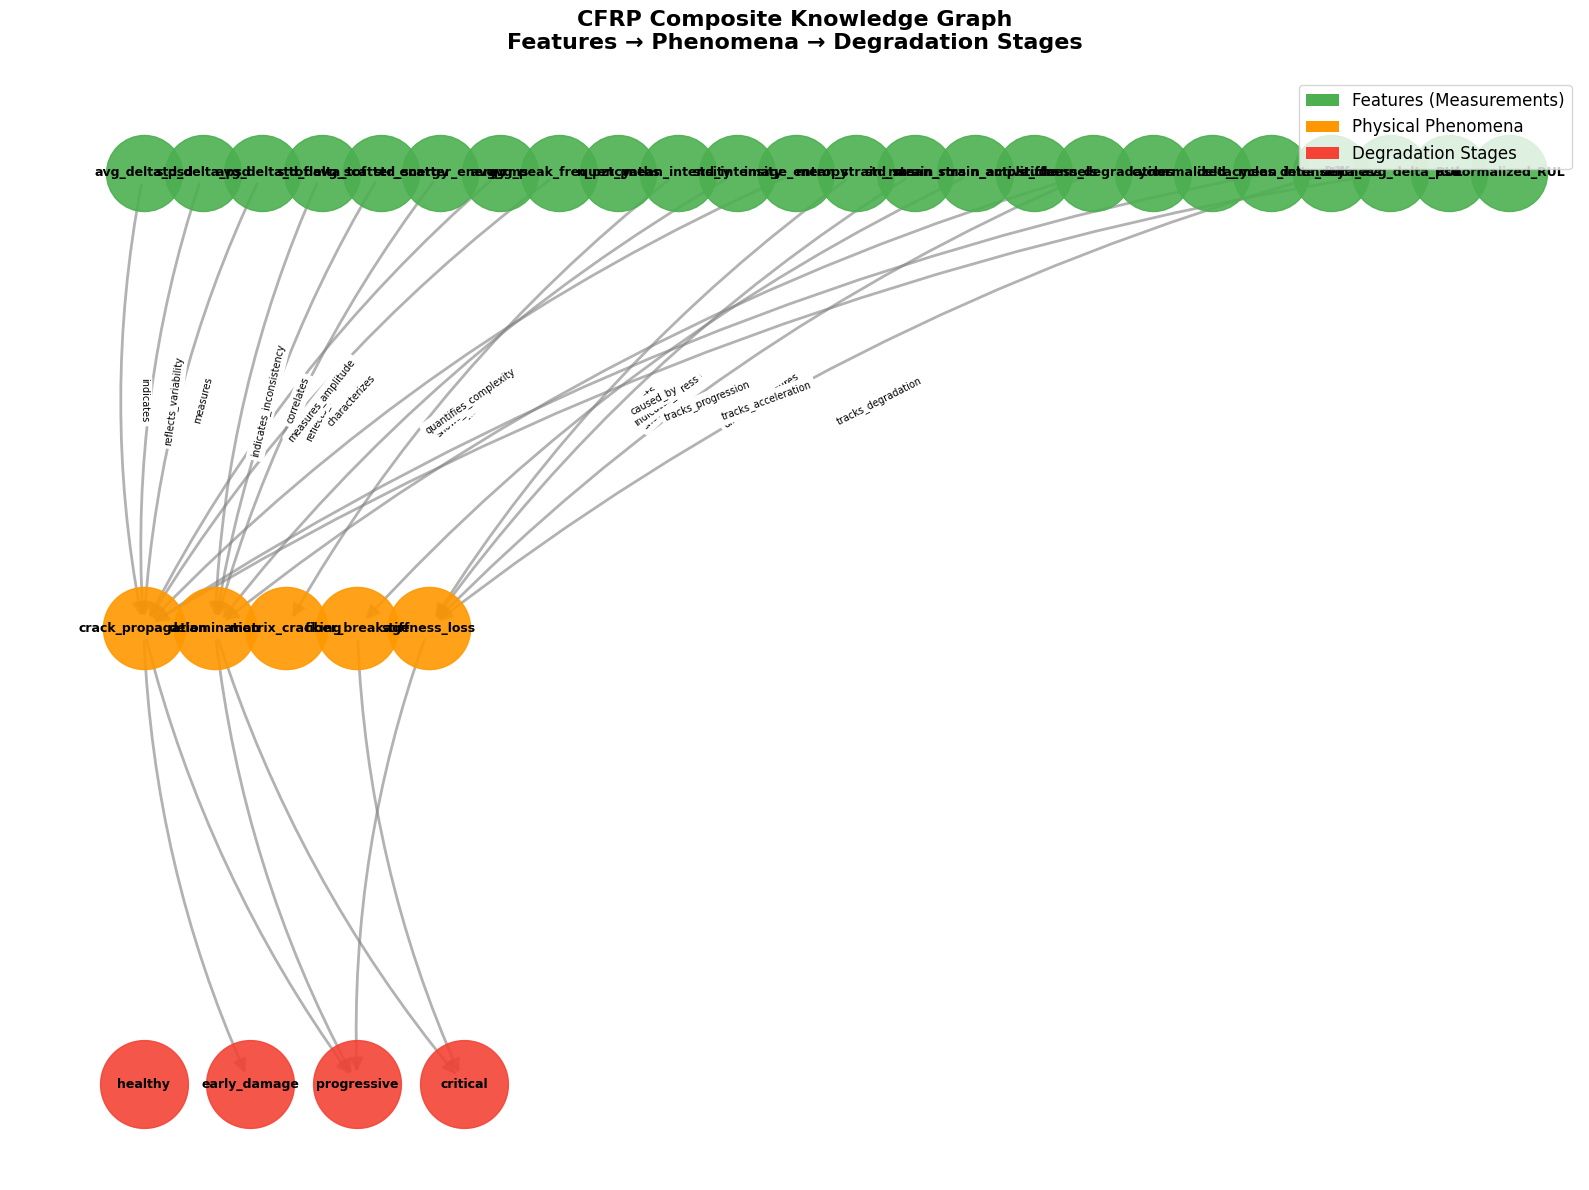

In [56]:
# Visualize Knowledge Graph
fig, ax = plt.subplots(figsize=(16, 12))

# Create hierarchical layout
pos = {}
feature_nodes = [n for n, d in kg.graph.nodes(data=True) if d.get('type') == 'feature']
phenomenon_nodes = [n for n, d in kg.graph.nodes(data=True) if d.get('type') == 'phenomenon']
stage_nodes = [n for n, d in kg.graph.nodes(data=True) if d.get('type') == 'stage']

# Position nodes in layers
y_levels = {'feature': 0, 'phenomenon': -3, 'stage': -6}
for i, node in enumerate(feature_nodes):
    pos[node] = (i * 2.5, y_levels['feature'])
for i, node in enumerate(phenomenon_nodes):
    pos[node] = (i * 3, y_levels['phenomenon'])
for i, node in enumerate(stage_nodes):
    pos[node] = (i * 4.5, y_levels['stage'])

# Draw nodes by type
node_colors = {'feature': '#4CAF50', 'phenomenon': '#FF9800', 'stage': '#F44336'}
node_sizes = {'feature': 3000, 'phenomenon': 3500, 'stage': 4000}

for node_type in ['feature', 'phenomenon', 'stage']:
    nodes = [n for n, d in kg.graph.nodes(data=True) if d.get('type') == node_type]
    nx.draw_networkx_nodes(kg.graph, pos, nodelist=nodes,
                          node_color=node_colors[node_type],
                          node_size=node_sizes[node_type],
                          alpha=0.9, ax=ax)

# Draw edges with arrows
nx.draw_networkx_edges(kg.graph, pos, edge_color='gray',
                      arrows=True, arrowsize=20, width=2,
                      alpha=0.6, ax=ax, connectionstyle='arc3,rad=0.1')

# Draw labels
nx.draw_networkx_labels(kg.graph, pos, font_size=9, font_weight='bold', ax=ax)

# Add edge labels (relation types)
edge_labels = nx.get_edge_attributes(kg.graph, 'relation')
nx.draw_networkx_edge_labels(kg.graph, pos, edge_labels, font_size=7, ax=ax)

# Title and legend
ax.set_title('CFRP Composite Knowledge Graph\nFeatures → Phenomena → Degradation Stages',
            fontsize=16, fontweight='bold', pad=20)
ax.axis('off')

# Add legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=node_colors['feature'], label='Features (Measurements)'),
    Patch(facecolor=node_colors['phenomenon'], label='Physical Phenomena'),
    Patch(facecolor=node_colors['stage'], label='Degradation Stages')
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=12)

plt.tight_layout()
plt.show()

## 3. Load Trained Models and Data

Load the trained models and test data for explanation generation.

In [57]:
# Load models and data
# NOTE: Update these paths based on your saved model locations
import pickle
from sklearn.preprocessing import MinMaxScaler

# Load scalers
# with open('../outputs/saved_models/feature_scaler.pkl', 'rb') as f:
with open('../outputs/saved_models/feature_scaler_combined.pkl', 'rb') as f:
    feature_scaler = pickle.load(f)
# with open('../outputs/saved_models/target_scaler.pkl', 'rb') as f:
with open('../outputs/saved_models/target_scaler_combined.pkl', 'rb') as f:
    target_scaler = pickle.load(f)

# Load test data
# with open('../outputs/saved_models/test_data.pkl', 'rb') as f:
with open('../outputs/saved_models/preprocessed_data_combined.pkl', 'rb') as f:
    test_data = pickle.load(f)
    X_test = test_data['X_test']
    y_test = test_data['y_test']  # ⚠️ These are NORMALIZED values (0-1 range)

print(f"Test data loaded: {X_test.shape[0]} samples")
print(f"Sequence length: {X_test.shape[1]}")
print(f"Features: {X_test.shape[2]}")

# ⚠️ Display target scaler info
print(f"\n{'='*80}")
print(f"TARGET SCALER INFORMATION:")
print(f"{'='*80}")
print(f"Original RUL Range: {target_scaler.data_min_[0]:.0f} to {target_scaler.data_max_[0]:.0f} cycles")
print(f"Normalized Range: 0.0 to 1.0")
print(f"\nExample conversions:")
print(f"  Normalized 0.00 → Actual {target_scaler.inverse_transform([[0.0]])[0, 0]:.0f} cycles")
print(f"  Normalized 0.50 → Actual {target_scaler.inverse_transform([[0.5]])[0, 0]:.0f} cycles")
print(f"  Normalized 1.00 → Actual {target_scaler.inverse_transform([[1.0]])[0, 0]:.0f} cycles")
print(f"{'='*80}\n")

# ⚠️ IMPORTANT: Use only the 20 features that models were trained with
# The models have input_dim=20, so we need exactly 20 feature names
feature_names = [
    # PZT sensor features (9)
    'avg_delta_psd', 'std_delta_psd', 'avg_delta_tof', 'std_delta_tof',
    'avg_scatter_energy', 'std_scatter_energy', 'avg_rms', 'avg_peak_frequency',
    'n_pzt_paths',
    # X-ray features (3)
    # 'mean_intensity', 'std_intensity', 'image_entropy',
    # Strain gauge features (4)
    'mean_strain_rms', 'std_strain_rms', 'mean_strain_amplitude', 'n_active_channels',
    # Mechanical features (1)
    'stiffness_degradation',
    # Temporal/derived features (3) - adjusted to match 20 total
    'cycles', 'normalized_cycles', 
    # 'RUL'
]

print(f"\n✅ Using {len(feature_names)} features (matching model input_dim={X_test.shape[2]}):")
for i, fname in enumerate(feature_names, 1):
    print(f"   {i:2d}. {fname}")

# Verify feature count matches
if len(feature_names) != X_test.shape[2]:
    print(f"\n⚠️  WARNING: Feature mismatch!")
    print(f"   Feature names: {len(feature_names)}")
    print(f"   Model expects: {X_test.shape[2]}")
else:
    print(f"\n✅ Feature count verified: {len(feature_names)} features match model input")

Test data loaded: 62 samples
Sequence length: 10
Features: 16

TARGET SCALER INFORMATION:
Original RUL Range: -3037 to 223963 cycles
Normalized Range: 0.0 to 1.0

Example conversions:
  Normalized 0.00 → Actual -3037 cycles
  Normalized 0.50 → Actual 110463 cycles
  Normalized 1.00 → Actual 223963 cycles


✅ Using 16 features (matching model input_dim=16):
    1. avg_delta_psd
    2. std_delta_psd
    3. avg_delta_tof
    4. std_delta_tof
    5. avg_scatter_energy
    6. std_scatter_energy
    7. avg_rms
    8. avg_peak_frequency
    9. n_pzt_paths
   10. mean_strain_rms
   11. std_strain_rms
   12. mean_strain_amplitude
   13. n_active_channels
   14. stiffness_degradation
   15. cycles
   16. normalized_cycles

✅ Feature count verified: 16 features match model input


In [58]:
# Load trained models
from modules.model_architecture import TransformerRULPredictor, LSTMRULPredictor
from modules.drl_models import DDPGActor

# Model hyperparameters (must match training configuration)
input_dim = 16  # Current training uses 20 features
d_model = 128
nhead = 8
num_layers = 3
hidden_dim = 128
model_configs = {
    'sequence_length': 10,  # 10
    'batch_size': 32,  # 32
    
    # Transformer parameters
    'transformer': {
        'input_dim': 16,  # 16 features (excluding RUL)
        'd_model': 64,
        'nhead': 4,
        'num_layers': 2,
        'dim_feedforward': 128,
        'dropout': 0.1,
        'lr': 1e-4,
        'weight_decay': 1e-5,
        'epochs': 100,
        'patience': 15
    },
    
    # LSTM parameters
    'lstm': {
        'input_dim': 16,  # 16 features (excluding RUL)
        'hidden_dim': 64,
        'num_layers': 2,
        'dropout': 0.2,
        'lr': 1e-3,
        'weight_decay': 1e-5,
        'epochs': 100,
        'patience': 15
    }
}

# Load Transformer model
transformer_config = model_configs['transformer']
transformer_model = TransformerRULPredictor(
    input_dim=transformer_config['input_dim'],
    d_model=transformer_config['d_model'],
    nhead=transformer_config['nhead'],
    num_layers=transformer_config['num_layers'],
    dim_feedforward=transformer_config['dim_feedforward'],
    dropout=transformer_config['dropout']
).to(device)
# transformer_model = TransformerRULPredictor(
#     input_dim=input_dim,
#     d_model=d_model,
#     nhead=nhead,
#     # num_layers=num_layers
# ).to(device)
transformer_model.load_state_dict(torch.load('../outputs/saved_models/transformer_rul_combined.pth', map_location=device))
# transformer_model.load_state_dict(torch.load('../outputs/saved_models/transformer_model.pth', map_location=device))
transformer_model.eval()
print("✓ Transformer model loaded")

# Load LSTM model
lstm_config = model_configs['lstm']
lstm_model = LSTMRULPredictor(
    input_dim=lstm_config['input_dim'],
    hidden_dim=lstm_config['hidden_dim'],
    num_layers=lstm_config['num_layers'],
    dropout=lstm_config['dropout']
).to(device)
# lstm_model = LSTMRULPredictor(
#     input_dim=input_dim,
#     hidden_dim=hidden_dim,
#     num_layers=num_layers
# ).to(device)
lstm_model.load_state_dict(torch.load('../outputs/saved_models/lstm_rul_combined.pth', map_location=device))
# lstm_model.load_state_dict(torch.load('../outputs/saved_models/lstm_model.pth', map_location=device))
lstm_model.eval()
print("✓ LSTM model loaded")

# Load DDPG Actor model
ddpg_model = DDPGActor(input_dim=input_dim, hidden_dim=hidden_dim).to(device)
ddpg_model.load_state_dict(torch.load('../outputs/saved_models/ddpg_actor.pth', map_location=device))
ddpg_model.eval()
print("✓ DDPG Actor model loaded")

print(f"\n✅ All models loaded successfully on {device}")

✓ Transformer model loaded
✓ LSTM model loaded
✓ DDPG Actor model loaded

✅ All models loaded successfully on cpu


In [59]:
# Diagnostic: Check model predictions across multiple samples
print(f"\n{'='*80}")
print(f"DIAGNOSTIC: Checking Model Predictions Across Samples")
print(f"{'='*80}\n")

# Test on a few samples
test_samples = [0, 10, 25, 50, 100]
print(f"{'Sample':<10} {'Actual (cycles)':<20} {'Trans. Pred':<15} {'LSTM Pred':<15} {'DDPG Pred':<15}")
print(f"{'-'*80}")

for idx in test_samples:
    if idx >= len(X_test):
        continue
    
    sample = X_test[idx:idx+1]
    actual_norm = float(y_test[idx])
    actual_cycles = target_scaler.inverse_transform([[actual_norm]])[0, 0]
    
    # Get predictions
    with torch.no_grad():
        trans_norm = transformer_model(torch.FloatTensor(sample).to(device)).cpu().item()
        lstm_norm = lstm_model(torch.FloatTensor(sample).to(device)).cpu().item()
        ddpg_norm = ddpg_model(torch.FloatTensor(sample).to(device)).cpu().item()
    
    trans_cycles = target_scaler.inverse_transform([[trans_norm]])[0, 0]
    lstm_cycles = target_scaler.inverse_transform([[lstm_norm]])[0, 0]
    ddpg_cycles = target_scaler.inverse_transform([[ddpg_norm]])[0, 0]
    
    print(f"{idx:<10} {actual_cycles:<20.0f} {trans_cycles:<15.0f} {lstm_cycles:<15.0f} {ddpg_cycles:<15.0f}")

print(f"\n{'='*80}")
print(f"⚠️  If predictions look flat or unreasonable:")
print(f"   1. Models may not be trained properly")
print(f"   2. Models may be outputting constant values (sigmoid saturation)")
print(f"   3. Training data may have issues")
print(f"{'='*80}\n")


DIAGNOSTIC: Checking Model Predictions Across Samples

Sample     Actual (cycles)      Trans. Pred     LSTM Pred       DDPG Pred      
--------------------------------------------------------------------------------
0          85000                84919           94535           -3002          
10         163963               171119          163098          -3002          
25         70000                74171           72715           223434         
50         90000                91214           94086           223560         

⚠️  If predictions look flat or unreasonable:
   1. Models may not be trained properly
   2. Models may be outputting constant values (sigmoid saturation)
   3. Training data may have issues



In [60]:
# Import RuleFit and query engine
from modules.rulefit import RuleFit, extract_rules_with_rulefit
from modules.query_engine import RuleQueryEngine

print("✓ RuleFit module imported")
print("✓ RuleQueryEngine module imported")

✓ RuleFit module imported
✓ RuleQueryEngine module imported


Rulefit on broader dataset

In [61]:
# RuleFit on broader dataset (train+val), test kept for evaluation

print("=" * 80)
print("RULEFIT RULE EXTRACTION (BROAD DATASET)")
print("=" * 80)

# 1) Load broader split artifact
with open("../outputs/saved_models/preprocessed_data_combined.pkl", "rb") as f:
    pre = pickle.load(f)

# Expected keys from combined preprocessing notebook
needed = ["X_train", "y_train", "X_val", "y_val", "X_test", "y_test"]
missing = [k for k in needed if k not in pre]
if missing:
    raise KeyError(f"Missing keys in preprocessed_data_combined.pkl: {missing}")

X_train = pre["X_train"]
y_train = pre["y_train"]
X_val = pre["X_val"]
y_val = pre["y_val"]
X_test_pool = pre["X_test"]      # keep as held-out evaluation
y_test_pool = pre["y_test"]

# 2) Build RuleFit pool from train+val only
X_rule_extract = np.concatenate([X_train, X_val], axis=0)
y_rule_extract_norm = np.concatenate([y_train, y_val], axis=0)
y_rule_extract_actual = target_scaler.inverse_transform(
    y_rule_extract_norm.reshape(-1, 1)
).flatten()

# 3) Stage boundaries
stage_boundaries = {"Early": 130000, "Mid": 80000}

def get_stage(rul_cycles):
    if rul_cycles >= stage_boundaries["Early"]:
        return "Early"
    elif rul_cycles >= stage_boundaries["Mid"]:
        return "Mid"
    else:
        return "Late"

stage_labels = np.array([get_stage(r) for r in y_rule_extract_actual])

print(f"Rule pool samples (train+val): {len(X_rule_extract)}")
print(f"Held-out test samples: {len(X_test_pool)}")
for s in ["Early", "Mid", "Late"]:
    c = (stage_labels == s).sum()
    print(f"  {s}: {c} ({100*c/len(stage_labels):.1f}%)")

# 4) Fit RuleFit on broad pool
rulefit = RuleFit(
    model=transformer_model,
    feature_names=feature_names,
    n_estimators=80,
    max_depth=4,
    memory_par=0.005,
    random_state=42,
    target_scaler=target_scaler,
    stage_boundaries=stage_boundaries,
)

rulefit.fit(X_rule_extract, y_rule_extract_actual, stage_labels)

rules_df = rulefit.get_rules_dataframe()
print(f"\nExtracted rules: {len(rules_df)}")
display(rules_df.head(15))

# 5) Build query engine from these broader rules
query_engine = RuleQueryEngine(
    rulefit=rulefit,
    feature_names=feature_names,
    stage_boundaries=stage_boundaries,
)
print("✓ RuleQueryEngine ready")

RULEFIT RULE EXTRACTION (BROAD DATASET)
Rule pool samples (train+val): 244
Held-out test samples: 62
  Early: 78 (32.0%)
  Mid: 90 (36.9%)
  Late: 76 (31.1%)

RULEFIT RULE EXTRACTION

1️⃣ Getting model predictions...
   ✓ Got 244 predictions
   Prediction range: [11053, 215812] cycles

2️⃣ Training tree ensemble...
   ✓ Trained 80 trees

3️⃣ Extracting rules from trees...
   ✓ Extracted 1241 candidate rules

4️⃣ Creating rule feature matrix...
   ✓ Created feature matrix: (244, 1241)

5️⃣ Selecting important rules with Lasso...


d:\pichla_laptop\IITG material\4th year\7th-sem\BTP-Explainable AI\2.+Composites\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:1622: FutureWarning: 'n_alphas' was deprecated in 1.7 and will be removed in 1.9. 'alphas' now accepts an integer value which removes the need to pass 'n_alphas'. The default value of 'alphas' will change from None to 100 in 1.9. Pass an explicit value to 'alphas' and leave 'n_alphas' to its default value to silence this warning.
  warnings.warn(


   ✓ Selected 177 important rules

6️⃣ Categorizing rules by stage...
   ✓ Categorized 177 final rules

✅ RULEFIT COMPLETE: 177 rules extracted

Extracted rules: 177


,rule_id,stage,conditions,condition_str,prediction,importance,support,avg_rul,coverage,specificity
0,RULE_112,Early,"[(stiffness_degradation, >, 0.0528608001768589...",stiffness_degradation > 0.052861 AND std_delta...,Normal,21435.075406,23,215506.015625,0.094262,4
1,RULE_042,Early,"[(normalized_cycles, <=, 0.4121665060520172), ...",normalized_cycles <= 0.412167 AND std_scatter_...,Normal,20516.358439,31,215001.906250,0.127049,4
2,RULE_163,Early,"[(std_scatter_energy, >, -0.5465129911899567),...",std_scatter_energy > -0.546513 AND std_scatter...,Normal,18118.535835,84,176659.312500,0.344262,4
3,RULE_113,Early,"[(stiffness_degradation, >, 0.0528608001768589...",stiffness_degradation > 0.052861 AND std_delta...,Normal,17020.995319,18,207007.328125,0.073770,4
4,RULE_091,Early,"[(normalized_cycles, <=, 0.19607767462730408),...",normalized_cycles <= 0.196078 AND std_delta_ps...,Normal,16516.447415,34,214738.156250,0.139344,4
5,RULE_135,Mid,"[(normalized_cycles, <=, 0.4121665060520172), ...",normalized_cycles <= 0.412167 AND std_delta_ps...,Warning,15693.953303,17,113714.242188,0.069672,4
6,RULE_122,Early,"[(std_delta_psd, <=, -0.5465075671672821), (st...",std_delta_psd <= -0.546508 AND std_scatter_ene...,Normal,15635.161737,6,177779.234375,0.024590,3
7,RULE_162,Early,"[(std_scatter_energy, >, -0.5465129911899567),...",std_scatter_energy > -0.546513 AND std_scatter...,Normal,14486.242783,9,182553.500000,0.036885,4
8,RULE_052,Mid,"[(cycles, <=, -0.13183261640369892), (avg_delt...",cycles <= -0.131833 AND avg_delta_psd <= 1.280...,Warning,13333.958510,13,96999.710938,0.053279,4
9,RULE_020,Early,"[(stiffness_degradation, >, -0.518728554248809...",stiffness_degradation > -0.518729 AND std_scat...,Normal,12959.313899,30,215141.640625,0.122951,4


✓ RuleQueryEngine ready


In [62]:
# Evaluate rule coverage/generalization on held-out test only
y_test_actual_holdout = target_scaler.inverse_transform(
    y_test_pool.reshape(-1, 1)
).flatten()

summary, query_results_df = query_engine.evaluate(
    X_test_pool, y_true=y_test_actual_holdout
)

print("=" * 80)
print("HELD-OUT TEST EVALUATION")
print("=" * 80)
for k, v in summary.items():
    if isinstance(v, float):
        print(f"{k}: {v:.4f}")
    else:
        print(f"{k}: {v}")

# Coverage by true stage
def stage_of(v):
    if v >= 130000:
        return "Early"
    elif v >= 80000:
        return "Mid"
    return "Late"

query_results_df["true_stage"] = [stage_of(v) for v in y_test_actual_holdout]
print("\nCoverage by true stage:")
print(query_results_df.groupby("true_stage")["covered"].mean())

HELD-OUT TEST EVALUATION
coverage_rate: 1.0000
avg_matched_rules: 19.1129
avg_confidence: 0.3149
mae: 20154.0850
rmse: 26383.9317

Coverage by true stage:
true_stage
Early    1.0
Late     1.0
Mid      1.0
Name: covered, dtype: float64


An attempt at implementing Querying 

In [63]:
# Cell: Extract rules using RuleFit algorithm
print("=" * 80)
print("RULEFIT RULE EXTRACTION")
print("=" * 80)

X_rule_extract = X_test
y_rule_extract_actual = target_scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

stage_boundaries = {
    "Early": 130000,
    "Mid": 80000,
}

def get_stage(rul_cycles):
    if rul_cycles >= stage_boundaries["Early"]:
        return "Early"
    elif rul_cycles >= stage_boundaries["Mid"]:
        return "Mid"
    else:
        return "Late"

stage_labels = np.array([get_stage(rul) for rul in y_rule_extract_actual])

print(f"\nDataset statistics:")
print(f"  Total samples: {len(X_rule_extract)}")
print(f"  Features: {len(feature_names)}")
print(f"\nStage distribution:")
for stage in ["Early", "Mid", "Late"]:
    count = (stage_labels == stage).sum()
    print(f"  {stage}: {count} samples ({count / len(stage_labels) * 100:.1f}%)")

rulefit = RuleFit(
    model=transformer_model,
    feature_names=feature_names,
    n_estimators=50,
    max_depth=4,
    memory_par=0.01,
    random_state=42,
    target_scaler=target_scaler,
    stage_boundaries=stage_boundaries,
)

rulefit.fit(X_rule_extract, y_rule_extract_actual, stage_labels)

rules_df = rulefit.get_rules_dataframe()
print(f"\nExtracted {len(rules_df)} final rules")
print(rules_df.head(10))

query_engine = RuleQueryEngine(
    rulefit=rulefit,
    feature_names=feature_names,
    stage_boundaries=stage_boundaries,
)

print("✓ Rule query engine initialized")
print("\n" + "=" * 80)

RULEFIT RULE EXTRACTION

Dataset statistics:
  Total samples: 62
  Features: 16

Stage distribution:
  Early: 20 samples (32.3%)
  Mid: 23 samples (37.1%)
  Late: 19 samples (30.6%)

RULEFIT RULE EXTRACTION

1️⃣ Getting model predictions...
   ✓ Got 62 predictions
   Prediction range: [11523, 215673] cycles

2️⃣ Training tree ensemble...
   ✓ Trained 50 trees

3️⃣ Extracting rules from trees...
   ✓ Extracted 665 candidate rules

4️⃣ Creating rule feature matrix...
   ✓ Created feature matrix: (62, 665)

5️⃣ Selecting important rules with Lasso...


d:\pichla_laptop\IITG material\4th year\7th-sem\BTP-Explainable AI\2.+Composites\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:1622: FutureWarning: 'n_alphas' was deprecated in 1.7 and will be removed in 1.9. 'alphas' now accepts an integer value which removes the need to pass 'n_alphas'. The default value of 'alphas' will change from None to 100 in 1.9. Pass an explicit value to 'alphas' and leave 'n_alphas' to its default value to silence this warning.
  warnings.warn(


   ✓ Selected 53 important rules

6️⃣ Categorizing rules by stage...
   ✓ Categorized 53 final rules

✅ RULEFIT COMPLETE: 53 rules extracted

Extracted 53 final rules
    rule_id  stage                                         conditions  \
0  RULE_008  Early  [(avg_delta_tof, >, -0.5039278864860535), (cyc...   
1  RULE_021  Early  [(normalized_cycles, <=, -0.24416149407625198)...   
2  RULE_024  Early  [(normalized_cycles, <=, 0.8362827301025391), ...   
3  RULE_009  Early  [(normalized_cycles, <=, 0.8362827301025391), ...   
4  RULE_020   Late  [(normalized_cycles, >, 0.08400251436978579), ...   
5  RULE_041  Early  [(stiffness_degradation, >, -0.962278246879577...   
6  RULE_027  Early  [(avg_delta_tof, <=, 0.4097521901130676), (std...   
7  RULE_035  Early  [(cycles, <=, -0.13183261640369892), (stiffnes...   
8  RULE_052  Early  [(std_scatter_energy, <=, 1.3177450299263), (s...   
9  RULE_026    Mid  [(cycles, <=, 0.16291688196361065), (avg_rms, ...   

                             

In [64]:
sample_idx = 25
sample = X_test[sample_idx:sample_idx + 1]

point_result = query_engine.point_query(
    sample,
    top_k=5,
    min_importance=0.0,
    return_all_matches=True,
)

print("=" * 80)
print(f"POINT QUERY FOR SAMPLE {sample_idx}")
print("=" * 80)
print(f"Predicted RUL from rules: {point_result['predicted_rul']:.0f} cycles")
print(f"Predicted stage: {point_result['predicted_stage']}")
print(f"Prediction label: {point_result['prediction_label']}")
print(f"Confidence: {point_result['confidence']:.3f}")
print(f"Matched rules: {point_result['n_matched_rules']}")

display_columns = [
    "rule_id",
    "stage",
    "prediction",
    "importance",
    "avg_rul",
    "coverage",
    "specificity",
    "condition_str",
]

display(point_result["top_rules"][display_columns])

POINT QUERY FOR SAMPLE 25
Predicted RUL from rules: 100339 cycles
Predicted stage: Mid
Prediction label: Warning
Confidence: 0.306
Matched rules: 3


,rule_id,stage,prediction,importance,avg_rul,coverage,specificity,condition_str
0,RULE_049,Mid,Warning,2330.090670,106161.390625,0.209677,4,avg_scatter_energy <= -0.426929 AND stiffness_...
1,RULE_050,Mid,Warning,1204.667560,90408.054688,0.129032,4,std_scatter_energy <= 1.317745 AND std_scatter...
2,RULE_028,Mid,Warning,173.871266,91111.187500,0.112903,4,normalized_cycles <= 0.913687 AND std_scatter_...


In [65]:
why_result = query_engine.why_query(sample, top_k=3, min_importance=0.0)

print("=" * 80)
print("WHY QUERY")
print("=" * 80)
print(why_result["summary"])

for idx, reason in enumerate(why_result["reasons"], start=1):
    print("\n" + "-" * 80)
    print(f"Reason {idx}: {reason['rule_id']}")
    print(f"Stage: {reason['stage']}")
    print(f"Prediction: {reason['prediction']}")
    print(f"Importance: {reason['importance']:.4f}")
    print(f"Average RUL: {reason['avg_rul']:.0f} cycles")
    print(f"Coverage: {reason['coverage'] * 100:.1f}%")
    print(f"Rule: IF {reason['condition_str']}")

    print("Evidence:")
    for item in reason["evidence"]:
        print(
            f"  {item['feature']}: actual={item['actual_value']:.6f}, "
            f"condition {item['operator']} {item['threshold']:.6f}, "
            f"satisfied={item['satisfied']}"
        )

WHY QUERY
Predicted stage: Mid with estimated RUL 100339 cycles. 3 rules matched this sample. The strongest supporting rule is RULE_049, which predicts Warning behavior and average RUL 106161 cycles.

--------------------------------------------------------------------------------
Reason 1: RULE_049
Stage: Mid
Prediction: Warning
Importance: 2330.0907
Average RUL: 106161 cycles
Coverage: 21.0%
Rule: IF avg_scatter_energy <= -0.426929 AND stiffness_degradation > -0.962278 AND avg_peak_frequency <= 0.457607 AND stiffness_degradation > -0.101552
Evidence:
  avg_scatter_energy: actual=-0.771459, condition <= -0.426929, satisfied=True
  stiffness_degradation: actual=0.105207, condition > -0.962278, satisfied=True
  avg_peak_frequency: actual=0.383563, condition <= 0.457607, satisfied=True
  stiffness_degradation: actual=0.105207, condition > -0.101552, satisfied=True

--------------------------------------------------------------------------------
Reason 2: RULE_050
Stage: Mid
Prediction: W

In [66]:
why_not_result = query_engine.why_not_query(
    sample,
    target_stage="Late",
    top_k=3,
    min_importance=0.0,
)

print("=" * 80)
print("WHY-NOT QUERY")
print("=" * 80)
print(why_not_result["summary"])
print(f"Actual predicted stage: {why_not_result['actual_stage']}")
print(f"Actual prediction label: {why_not_result['actual_prediction']}")

for idx, candidate in enumerate(why_not_result["candidate_rules"], start=1):
    print("\n" + "-" * 80)
    print(f"Candidate Rule {idx}: {candidate['rule_id']}")
    print(f"Target stage: {candidate['target_stage']}")
    print(f"Target prediction: {candidate['target_prediction']}")
    print(f"Importance: {candidate['importance']:.4f}")
    print(f"Rule: IF {candidate['condition_str']}")
    print(f"Failed conditions: {candidate['n_failed_conditions']}")

    for item in candidate["failed_conditions"]:
        print(
            f"  FAILED -> {item['feature']}: actual={item['actual_value']:.6f}, "
            f"needs {item['operator']} {item['threshold']:.6f}, "
            f"distance={item['distance_to_satisfy']:.6f}"
        )

WHY-NOT QUERY
The sample was not assigned to target outcome (stage=Late, prediction=None) because the closest supporting rule RULE_023 failed 1 condition(s).
Actual predicted stage: Mid
Actual prediction label: Warning

--------------------------------------------------------------------------------
Candidate Rule 1: RULE_023
Target stage: Late
Target prediction: Critical
Importance: 10660.8408
Rule: IF cycles <= 0.605041 AND avg_scatter_energy <= -0.499075 AND stiffness_degradation <= 0.443332 AND std_delta_psd > -1.121010
Failed conditions: 1
  FAILED -> std_delta_psd: actual=-1.454176, needs > -1.121010, distance=0.333167

--------------------------------------------------------------------------------
Candidate Rule 2: RULE_020
Target stage: Late
Target prediction: Critical
Importance: 25826.8970
Rule: IF normalized_cycles > 0.084003 AND avg_scatter_energy > -0.997805 AND normalized_cycles > 1.615138 AND normalized_cycles > 1.824129
Failed conditions: 2
  FAILED -> normalized_cycle

In [88]:
what_if_result = query_engine.what_if_query(
    sample,
    feature_changes={
        "stiffness_degradation": 0.70,
        "mean_strain_rms": 0.85,
    },
    top_k=5,
    min_importance=0.0,
)

print("=" * 80)
print("WHAT-IF QUERY")
print("=" * 80)
print(what_if_result["summary"])
print(f"Stage changed: {what_if_result['stage_changed']}")
print(f"Prediction changed: {what_if_result['prediction_changed']}")
print(f"Delta RUL: {what_if_result['delta_rul']:.2f} cycles")

print("\nOriginal:")
print(f"  Stage: {what_if_result['original']['predicted_stage']}")
print(f"  Prediction: {what_if_result['original']['prediction_label']}")
print(f"  RUL: {what_if_result['original']['predicted_rul']:.0f}")

print("\nModified:")
print(f"  Stage: {what_if_result['modified']['predicted_stage']}")
print(f"  Prediction: {what_if_result['modified']['prediction_label']}")
print(f"  RUL: {what_if_result['modified']['predicted_rul']:.0f}")

WHAT-IF QUERY
Original stage=Mid, modified stage=Mid. Original RUL=100339 cycles, modified RUL=101650 cycles.
Stage changed: False
Prediction changed: False
Delta RUL: 1311.04 cycles

Original:
  Stage: Mid
  Prediction: Warning
  RUL: 100339

Modified:
  Stage: Mid
  Prediction: Warning
  RUL: 101650


In [68]:
counterfactual_result = query_engine.counterfactual_query(
    sample,
    target_stage="Late",
    top_k=10,
    min_importance=0.0,
)

print("=" * 80)
print("COUNTERFACTUAL QUERY")
print("=" * 80)
print(counterfactual_result["summary"])

if counterfactual_result["counterfactual_found"]:
    best_cf = counterfactual_result["best_counterfactual"]

    print("\nBest counterfactual rule:")
    print(f"  Rule ID: {best_cf['rule_id']}")
    print(f"  Target stage: {best_cf['target_stage']}")
    print(f"  Target prediction: {best_cf['target_prediction']}")
    print(f"  Importance: {best_cf['importance']:.4f}")
    print(f"  Failed conditions: {best_cf['n_failed_conditions']}")
    print(f"  Total change cost: {best_cf['total_change_cost']:.6f}")
    print(f"  Rule: IF {best_cf['condition_str']}")

    print("\nSuggested feature changes:")
    for feature_name, value in best_cf["proposed_changes"].items():
        print(f"  {feature_name} -> {value:.6f}")

    print("\nCurrent result:")
    print(f"  Stage: {counterfactual_result['current_result']['predicted_stage']}")
    print(f"  Prediction: {counterfactual_result['current_result']['prediction_label']}")
    print(f"  RUL: {counterfactual_result['current_result']['predicted_rul']:.0f}")

    print("\nModified result after counterfactual:")
    print(f"  Stage: {counterfactual_result['modified_result']['predicted_stage']}")
    print(f"  Prediction: {counterfactual_result['modified_result']['prediction_label']}")
    print(f"  RUL: {counterfactual_result['modified_result']['predicted_rul']:.0f}")

COUNTERFACTUAL QUERY
Closest counterfactual for target outcome (stage=Late, prediction=None) is to modify 1 feature(s). Suggested rule: RULE_029.

Best counterfactual rule:
  Rule ID: RULE_029
  Target stage: Late
  Target prediction: Critical
  Importance: 4084.0317
  Failed conditions: 1
  Total change cost: 0.266027
  Rule: IF std_scatter_energy <= 1.587187 AND stiffness_degradation <= -0.160820 AND avg_delta_psd <= -0.290709 AND avg_rms > -1.035048

Suggested feature changes:
  stiffness_degradation -> -0.160820

Current result:
  Stage: Mid
  Prediction: Warning
  RUL: 100339

Modified result after counterfactual:
  Stage: Late
  Prediction: Warning
  RUL: 62706


In [69]:
# Query 1: Which features strongly influence late-stage RUL predictions?
q1 = query_engine.global_feature_influence_query(
    stage="Late",
    top_k=10,
    min_importance=0.0,
    weight_by="importance_x_coverage",  # or "importance"
)
print(q1["summary"])
display(q1["feature_ranking"])

Computed global feature influence from 15 rules (stage=Late, prediction=None).


,feature,weighted_score,rule_count,avg_rule_coverage,avg_rule_specificity,example_conditions,normalized_score
0,normalized_cycles,16743.148328,13,0.110422,3.923077,normalized_cycles > 0.084003 | normalized_cycl...,1.000000
1,avg_scatter_energy,4674.811998,4,0.104839,4.000000,avg_scatter_energy <= -0.499075 | avg_scatter_...,0.279207
2,std_delta_tof,3080.327253,7,0.101382,4.000000,std_delta_tof <= 1.377321 | std_delta_tof > 0....,0.183975
3,stiffness_degradation,2894.878354,8,0.080645,3.750000,stiffness_degradation <= -2.267970 | stiffness...,0.172899
4,avg_rms,2053.031974,4,0.129032,4.000000,avg_rms <= -0.394233 | avg_rms <= 1.049379 | a...,0.122619
5,std_delta_psd,1935.313568,5,0.087097,4.000000,std_delta_psd > -1.121010 | std_delta_psd > -0...,0.115588
6,avg_delta_psd,1823.068347,3,0.134409,3.666667,avg_delta_psd > -0.874505 | avg_delta_psd <= -...,0.108884
7,std_scatter_energy,1261.039181,4,0.116935,4.000000,std_scatter_energy <= 1.317745 | std_scatter_e...,0.075317
8,cycles,1168.023126,5,0.106452,4.000000,cycles > -0.711507 | cycles <= 1.882289 | cycl...,0.069761
9,avg_delta_tof,855.324572,4,0.076613,3.750000,avg_delta_tof <= 0.877235 | avg_delta_tof > 0....,0.051085


In [70]:
# Query 2: What degradation patterns are associated with high PZT TOF values?
# avg_delta_tof is your PZT TOF feature
q2 = query_engine.cohort_pattern_query(
    X=X_test_pool,                     # or X_test
    feature_name="avg_delta_tof",
    operator=">",
    quantile=0.90,                     # "high TOF" = top 10%
    y_true=y_test_actual_holdout,      # optional but recommended for stage patterns
    top_k_features=10,
    top_k_rules=5,
)
print(q2["summary"])
print("\nTop shifted features:")
display(q2["feature_differences"])

print("\nStage shift (cohort vs complement):")
display(q2["stage_pattern"])

print("\nRules associated with high TOF:")
display(q2["supporting_rules"][["rule_id", "stage", "prediction", "importance", "condition_str"]])

Cohort query for avg_delta_tof > 1.508649: 7/62 samples (11.3%).

Top shifted features:


,feature,cohort_mean,complement_mean,delta,abs_delta
0,avg_delta_tof,1.756588,-0.107956,1.864543,1.864543
1,std_delta_tof,1.384026,-0.049163,1.433190,1.433190
2,avg_peak_frequency,-1.211859,0.034370,-1.246228,1.246228
3,avg_rms,-1.048848,-0.053096,-0.995752,0.995752
4,avg_scatter_energy,-0.853755,-0.107619,-0.746136,0.746136
5,avg_delta_psd,-0.853752,-0.107620,-0.746132,0.746132
6,normalized_cycles,0.856329,0.122861,0.733468,0.733468
7,stiffness_degradation,-0.796521,-0.130444,-0.666078,0.666078
8,cycles,0.710309,0.211394,0.498915,0.498915
9,std_scatter_energy,-0.185020,0.022447,-0.207467,0.207467



Stage shift (cohort vs complement):


,stage,cohort_fraction,complement_fraction,delta_fraction
0,Late,0.571429,0.272727,0.298701
1,Mid,0.285714,0.381818,-0.096104
2,Early,0.142857,0.345455,-0.202597



Rules associated with high TOF:


,rule_id,stage,prediction,importance,condition_str
0,RULE_008,Early,Normal,36092.330055,avg_delta_tof > -0.503928 AND cycles > -0.3283...
1,RULE_021,Early,Normal,33117.268493,normalized_cycles <= -0.244161 AND avg_delta_t...
2,RULE_027,Early,Normal,19124.687781,avg_delta_tof <= 0.409752 AND std_delta_psd > ...
3,RULE_052,Early,Normal,18441.292880,std_scatter_energy <= 1.317745 AND std_scatter...
4,RULE_026,Mid,Warning,17910.161714,cycles <= 0.162917 AND avg_rms <= -0.236061 AN...


In [71]:
# SHAP vs RuleQueryEngine benchmarking (same sample)

from modules import SHAPBenchmarkExplainer

# 1) Pick model and data
model_to_evaluate = transformer_model
sample_idx = 25

# Use validation as SHAP background (faster and stable)
background_samples = X_val[:100] if len(X_val) >= 100 else X_val

# Explain one sequence (shape: [1, seq_len, n_features])
target_sample = X_test_pool[sample_idx:sample_idx + 1]

# 2) Build SHAP benchmark explainer
shap_benchmarker = SHAPBenchmarkExplainer(
    model=model_to_evaluate,
    background_data=background_samples,
    feature_names=feature_names,
    device=str(device),
    max_background=100,
    prefer_deep=False,
)

# 3) SHAP top-k feature importances
shap_importances = shap_benchmarker.get_feature_importances(
    target_sequence=target_sample,
    top_k=5
)

# 4) Rule-based local explanation for the same sample
# query_engine accepts sequence input and internally uses last timestep for matching
rule_why = query_engine.why_query(
    sample=target_sample,
    top_k=3,
    min_importance=0.0
)

# 5) Print side-by-side benchmark
print("=" * 80)
print("XAI BENCHMARK: RuleQueryEngine vs SHAP")
print("=" * 80)
print(f"Model: {model_to_evaluate.__class__.__name__}")
print(f"Sample index: {sample_idx}")

# Optional: show model prediction in cycles for context
pred_norm = float(model_to_evaluate(torch.FloatTensor(target_sample).to(device)).detach().cpu().numpy().squeeze())
pred_cycles = float(target_scaler.inverse_transform([[pred_norm]])[0, 0])
print(f"Predicted RUL: {pred_cycles:.0f} cycles (normalized={pred_norm:.4f})")

print("\n[RuleQueryEngine] WHY summary:")
print(rule_why.get("summary", "No summary returned"))

reasons = rule_why.get("reasons", [])
if reasons:
    print("\nTop matched rules:")
    for i, r in enumerate(reasons[:3], start=1):
        print(
            f"  {i}. {r['rule_id']} | stage={r['stage']} | "
            f"prediction={r['prediction']} | importance={r['importance']:.4f}"
        )
        print(f"     IF {r['condition_str']}")
else:
    print("  No matched rules for this sample.")

print("\n[SHAP] Top 5 aggregated features (mean |SHAP| over sequence):")
for i, (feat, score) in enumerate(shap_importances, start=1):
    print(f"  {i}. {feat}: {score:.6f}")

print("=" * 80)

XAI BENCHMARK: RuleQueryEngine vs SHAP
Model: TransformerRULPredictor
Sample index: 25
Predicted RUL: 74171 cycles (normalized=0.3401)

[RuleQueryEngine] WHY summary:
Predicted stage: Mid with estimated RUL 100339 cycles. 3 rules matched this sample. The strongest supporting rule is RULE_049, which predicts Warning behavior and average RUL 106161 cycles.

Top matched rules:
  1. RULE_049 | stage=Mid | prediction=Warning | importance=2330.0907
     IF avg_scatter_energy <= -0.426929 AND stiffness_degradation > -0.962278 AND avg_peak_frequency <= 0.457607 AND stiffness_degradation > -0.101552
  2. RULE_050 | stage=Mid | prediction=Warning | importance=1204.6676
     IF std_scatter_energy <= 1.317745 AND std_scatter_energy <= -0.568709 AND cycles <= -0.131833 AND std_delta_tof > -0.493313
  3. RULE_028 | stage=Mid | prediction=Warning | importance=173.8713
     IF normalized_cycles <= 0.913687 AND std_scatter_energy <= -0.604200 AND avg_delta_tof > -0.252794 AND std_scatter_energy > -1.55

In [72]:
summary, query_results_df = query_engine.evaluate(X_test, y_true=y_rule_extract_actual)

print("=" * 80)
print("RULE QUERY EVALUATION")
print("=" * 80)
for key, value in summary.items():
    if isinstance(value, float):
        print(f"{key}: {value:.4f}")
    else:
        print(f"{key}: {value}")

display(query_results_df.head(20))

RULE QUERY EVALUATION
coverage_rate: 1.0000
avg_matched_rules: 8.1935
avg_confidence: 0.3816
mae: 27630.3093
rmse: 33022.7335


,sample_idx,predicted_rul_rulefit,predicted_stage_rulefit,prediction_label_rulefit,confidence,n_matched_rules,covered,actual_rul,abs_error
0,0,102523.311539,Mid,Warning,0.256293,8,True,85000.0,17523.311539
1,1,25308.208901,Late,Critical,0.355462,4,True,25000.0,308.208901
2,2,27367.608949,Late,Critical,0.376605,6,True,20000.0,7367.608949
3,3,31169.529297,Late,Critical,0.309934,1,True,48963.0,17793.470703
4,4,105326.129136,Mid,Critical,0.211921,6,True,73963.0,31363.129136
5,5,23879.986960,Late,Critical,0.376890,6,True,10000.0,13879.986960
6,6,160438.096770,Early,Normal,0.398204,6,True,99990.0,60448.096770
7,7,62661.420816,Late,Critical,0.254428,7,True,48963.0,13698.420816
8,8,172383.871041,Early,Normal,0.571012,15,True,213963.0,41579.128959
9,9,20655.043987,Late,Critical,0.381238,7,True,-3037.0,23692.043987


Earlier rule generation(only)

In [73]:
# # Cell: Extract rules using RuleFit algorithm
# print("=" * 80)
# print("RULEFIT RULE EXTRACTION")
# print("=" * 80)

# # Prepare data
# X_rule_extract = X_test
# y_rule_extract_actual = target_scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

# # Define stage labels
# def get_stage(rul_cycles):
#     if rul_cycles >= 130000:
#         return 'Early'
#     elif rul_cycles >= 80000:
#         return 'Mid'
#     else:
#         return 'Late'

# stage_labels = np.array([get_stage(rul) for rul in y_rule_extract_actual])

# print(f"\nDataset statistics:")
# print(f"  Total samples: {len(X_rule_extract)}")
# print(f"  Features: {len(feature_names)}")
# print(f"\nStage distribution:")
# for stage in ['Early', 'Mid', 'Late']:
#     count = (stage_labels == stage).sum()
#     print(f"  {stage}: {count} samples ({count/len(stage_labels)*100:.1f}%)")

# # Extract rules using RuleFit
# rulefit = RuleFit(
#     model=transformer_model,
#     feature_names=feature_names,
#     n_estimators=50,  # Number of trees in ensemble
#     max_depth=4,      # Maximum tree depth (deeper = more complex rules)
#     memory_par=0.01,  # Lasso regularization (lower = more rules)
#     random_state=42
# )

# # Fit RuleFit
# rulefit.fit(X_rule_extract, y_rule_extract_actual, stage_labels)

# print("\n" + "=" * 80)

In [74]:
# # Display top rules overall
# print("\n📊 TOP 20 RULES BY IMPORTANCE")
# rulefit.print_rules(top_k=20, min_importance=0.0)

# # Display rules by stage
# for stage in ['Early', 'Mid', 'Late']:
#     print(f"\n{'='*80}")
#     print(f"🎯 TOP RULES FOR {stage.upper()} STAGE")
#     print(f"{'='*80}")
#     rulefit.print_rules(stage=stage, top_k=5)

# # Get rules as DataFrame
# rules_df = rulefit.get_rules_dataframe()

# print(f"\n{'='*80}")
# print("RULE STATISTICS")
# print(f"{'='*80}")
# print(f"\nTotal rules extracted: {len(rules_df)}")

# if not rules_df.empty:
#     print(f"\nBy stage:")
#     for stage in ['Early', 'Mid', 'Late']:
#         count = (rules_df['stage'] == stage).sum()
#         print(f"  {stage}: {count} rules")
    
#     print(f"\nBy prediction:")
#     for pred in rules_df['prediction'].unique():
#         count = (rules_df['prediction'] == pred).sum()
#         print(f"  {pred}: {count} rules")
    
#     print(f"\nImportance statistics:")
#     print(f"  Mean: {rules_df['importance'].mean():.4f}")
#     print(f"  Max: {rules_df['importance'].max():.4f}")
#     print(f"  Min: {rules_df['importance'].min():.4f}")
    
#     print(f"\nCoverage statistics:")
#     print(f"  Mean: {rules_df['coverage'].mean()*100:.1f}%")
#     print(f"  Max: {rules_df['coverage'].max()*100:.1f}%")
# else:
#     print("⚠️  No rules extracted!")

# print(f"{'='*80}")

In [75]:
# Cell: Import Knowledge Trepan

from modules.knowledge_trepan import KnowledgeTrepan

print("✓ Knowledge Trepan module imported")

✓ Knowledge Trepan module imported


In [76]:
# Cell: Extract rules using Knowledge Trepan

print("=" * 80)
print("KNOWLEDGE TREPAN RULE EXTRACTION")
print("=" * 80)

# Initialize Knowledge Trepan
kt = KnowledgeTrepan(
    model=transformer_model,  # or lstm_model, ddpg_model
    device=device,
    feature_names=feature_names,
    target_scaler=target_scaler,
    max_depth=6,              # Deeper tree = more complex rules
    min_samples_split=100,    # Minimum samples to split
    min_samples_leaf=50,      # Minimum samples in leaf
    sample_size=1000,         # Samples per node expansion
    synthetic_ratio=0.5,      # 50% synthetic samples
    random_state=42
)

# Fit on test data (or use X_train if you have it)
kt.fit(X_test, y_test)

# Print top rules
kt.print_rules(top_k=15, min_coverage=0.02)

# Get feature importance
print(f"\n📊 TOP 10 FEATURE IMPORTANCE (from tree):")
for feat, imp in kt.get_feature_importance(top_k=10).items():
    print(f"   {feat:30s}: {imp:.4f}")

KNOWLEDGE TREPAN RULE EXTRACTION

KNOWLEDGE TREPAN RULE EXTRACTION

📊 Dataset Configuration:
   Real samples: 62
   Synthetic samples: 31
   Total samples: 93
   Sequence length: 10
   Features: 16

🔄 Generating synthetic samples...
🔄 Querying model for predictions...

📈 Prediction Statistics:
   Mean RUL: 107448 cycles
   Std RUL: 62761 cycles
   Min RUL: 10857 cycles
   Max RUL: 215673 cycles

🌳 Building decision tree...
   Max depth: 6
   Min samples split: 100
   Min samples leaf: 50

📋 Extracting rules from tree...

✅ Extraction complete!
   Total rules extracted: 1
   Tree nodes: 1
   Tree leaves: 1

TOP 1 RULES (Coverage >= 2.0%)

Rule 1:
  IF 
  THEN RUL ≈ 107448 cycles
  Coverage: 100.0% (93 samples)
  Complexity: 0 conditions
  Impurity: 3938967786.5364


📊 TOP 10 FEATURE IMPORTANCE (from tree):
   avg_delta_psd                 : 0.0000
   std_delta_psd                 : 0.0000
   avg_delta_tof                 : 0.0000
   std_delta_tof                 : 0.0000
   avg_scatter_

In [77]:
# Cell: Evaluate Knowledge Trepan fidelity

# Check how well tree approximates neural network
fidelity = kt.evaluate_fidelity(X_test)

print(f"\n{'='*80}")
print(f"KNOWLEDGE TREPAN FIDELITY METRICS")
print(f"{'='*80}")
print(f"\n📊 How well does the tree approximate the neural network?")
print(f"   MAE: {fidelity['mae']:.0f} cycles")
print(f"   RMSE: {fidelity['rmse']:.0f} cycles")
print(f"   R²: {fidelity['r2']:.4f}")
print(f"   Agreement (±10%): {fidelity['agreement']*100:.1f}%")

if fidelity['r2'] > 0.8:
    print(f"\n   ✅ EXCELLENT fidelity - tree closely matches neural network")
elif fidelity['r2'] > 0.6:
    print(f"\n   ✓ GOOD fidelity - tree captures main patterns")
else:
    print(f"\n   ⚠️  LOW fidelity - tree may oversimplify neural network")
    print(f"      Try increasing max_depth or min_samples_leaf")

print(f"{'='*80}")


KNOWLEDGE TREPAN FIDELITY METRICS

📊 How well does the tree approximate the neural network?
   MAE: 50164 cycles
   RMSE: 62491 cycles
   R²: -0.0029
   Agreement (±10%): 19.4%

   ⚠️  LOW fidelity - tree may oversimplify neural network
      Try increasing max_depth or min_samples_leaf


In [78]:
# Cell: Import ALPA

from modules.alpa import ALPA

print("✓ ALPA module imported")

✓ ALPA module imported


In [79]:
# Cell: Extract rules using ALPA

print("=" * 80)
print("ALPA LOGIC RULE EXTRACTION")
print("=" * 80)

# Initialize ALPA
alpa = ALPA(
    model=transformer_model,  # or lstm_model, ddpg_model
    device=device,
    feature_names=feature_names,
    target_scaler=target_scaler,
    min_confidence=0.6,       # Lower = more rules
    min_support=30,           # Minimum samples per rule
    min_precision=0.65,       # Minimum precision threshold
    max_rule_length=4,        # Maximum conditions per rule
    beam_width=15,            # Beam search width
    n_quantiles=5,            # Feature discretization bins
    random_state=42
)

# Fit ALPA (extracts logic rules)
alpa.fit(X_test, y_test)

# Print all rules
alpa.print_rules(top_k=20, sort_by='confidence')

ALPA LOGIC RULE EXTRACTION

ALPA LOGIC RULE EXTRACTION

📊 Dataset Configuration:
   Samples: 62
   Sequence length: 10
   Features: 16

🔄 Discretizing features into 5 bins...
   Discretization complete. Thresholds:
      avg_delta_psd: [-0.81079458 -0.51126768 -0.15395955  0.43426611]
      std_delta_psd: [-1.00971949 -0.45866428  0.20887384  0.82637223]
      avg_delta_tof: [-0.728929   -0.21538521  0.24882738  0.84540547]
      std_delta_tof: [-0.59280753 -0.21238684  0.12521971  0.66852242]
      avg_scatter_energy: [-0.81079288 -0.51126944 -0.15395716  0.43426725]
      ... (11 more features)

🔄 Querying model for predictions...

🎯 Stage Distribution:
   critical            :   15 samples ( 24.2%)
   progressive         :   23 samples ( 37.1%)
   early_damage        :   11 samples ( 17.7%)
   healthy             :   13 samples ( 21.0%)

🔍 Extracting rules using beam search...
   Min confidence: 0.6
   Min support: 30
   Min precision: 0.65
   Beam width: 15

   🎯 Stage: critical...

In [80]:
# Cell: Import REFNE

from modules.refne import REFNE

print("✓ REFNE module imported")

✓ REFNE module imported


In [81]:
# Cell: Extract rules using REFNE

print("=" * 80)
print("REFNE RULE EXTRACTION")
print("=" * 80)

# Initialize REFNE
refne = REFNE(
    model=transformer_model,  # or lstm_model, ddpg_model
    device=device,
    feature_names=feature_names,
    target_scaler=target_scaler,
    ensemble_method='random_forest',  # 'random_forest', 'gradient_boosting', 'bagging'
    n_estimators=100,         # Number of trees in ensemble
    max_depth=6,              # Maximum tree depth
    min_samples_split=50,     # Minimum samples to split
    min_samples_leaf=20,      # Minimum samples in leaf
    synthetic_ratio=0.3,      # 30% synthetic samples
    min_ensemble_votes=5,     # Minimum trees supporting a rule
    min_rule_confidence=0.6,  # Minimum confidence threshold
    random_state=42
)

# Fit REFNE
refne.fit(X_test, y_test)

# Print top rules
refne.print_rules(top_k=20, sort_by='votes')

REFNE RULE EXTRACTION

REFNE (Rule Extraction from Neural Network Ensemble)

📊 Dataset Configuration:
   Real samples: 62
   Synthetic ratio: 0.3
   Sequence length: 10
   Features: 16

🔄 Generating 18 synthetic samples...

🔄 Querying neural network for predictions...

📈 Prediction Statistics:
   Mean RUL: 110557 cycles
   Std RUL: 63710 cycles
   Min RUL: 11523 cycles
   Max RUL: 215673 cycles

🌳 Building random_forest ensemble...
   Number of trees: 100
   Max depth: 6
   ✅ Ensemble trained

📋 Extracting rules from 100 trees...
   Processed 20/100 trees...
   Processed 40/100 trees...
   Processed 60/100 trees...
   Processed 80/100 trees...
   Processed 100/100 trees...
   ✅ Extracted 172 total rules from all trees

🔄 Consolidating rules via ensemble voting...
   Found 37 unique rule patterns
   ✅ Consolidated to 0 high-quality rules
   (Min votes: 5, Min confidence: 0.6)

✅ REFNE extraction complete!
   Ensemble trees: 100
   Total tree rules: 172
   Consolidated rules: 0
   Avg en

d:\pichla_laptop\IITG material\4th year\7th-sem\BTP-Explainable AI\2.+Composites\.venv\Lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
d:\pichla_laptop\IITG material\4th year\7th-sem\BTP-Explainable AI\2.+Composites\.venv\Lib\site-packages\numpy\_core\_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


## 4. Initialize XAI Explainers

Create explainer instances for all models using the knowledge graph.

In [82]:
# Create explainers for all models
transformer_explainer = XAIExplainer(kg, device)
lstm_explainer = XAIExplainer(kg, device)
ddpg_explainer = XAIExplainer(kg, device)
print("✓ XAI Explainers initialized (Transformer, LSTM, DDPG)")

✓ XAI Explainers initialized (Transformer, LSTM, DDPG)


## 5. Generate Explanation for Sample

Generate detailed explanation for a test sample using the Transformer model.

In [83]:
# Generate explanation
sample_idx = 25
sample_sequence = X_test[sample_idx:sample_idx+1]
actual_rul_normalized = float(y_test[sample_idx])
actual_rul = target_scaler.inverse_transform([[actual_rul_normalized]])[0, 0]

print(f"Sample shape: {sample_sequence.shape}")
print(f"Analyzing sample at cycle: {sample_sequence[0, -1, feature_names.index('cycles')]}")

# ⚠️ CRITICAL: Pass target_scaler to explainer for inverse transformation!
transformer_exp = transformer_explainer.explain_prediction(
    model=transformer_model,
    sample=sample_sequence,
    feature_names=feature_names,
    model_type='transformer',
    top_k=10,  # Show top 10 features instead of just 5
    target_scaler=target_scaler  # Required for de-normalization!
)

# Add actual RUL to explanation
transformer_exp['actual_rul'] = actual_rul

print(f"\n{'='*80}")
print(f"TRANSFORMER EXPLANATION FOR SAMPLE {sample_idx}")
print(f"{'='*80}")

print(f"\n📊 Predicted RUL: {transformer_exp['predicted_rul']:.0f} cycles")
print(f"    (normalized: {transformer_exp['predicted_rul_normalized']:.4f})")
print(f"🎯 Actual RUL: {transformer_exp['actual_rul']:.0f} cycles")
print(f"    (normalized: {actual_rul_normalized:.4f})")
print(f"📉 Error: {abs(transformer_exp['predicted_rul'] - transformer_exp['actual_rul']):.0f} cycles")
print(f"    ({abs(transformer_exp['predicted_rul'] - transformer_exp['actual_rul'])/transformer_exp['actual_rul']*100:.1f}% error)")

print(f"\n🔍 TOP {len(transformer_exp['feature_importances'])} FEATURE CONTRIBUTIONS:")
for i, (feature, importance) in enumerate(transformer_exp['feature_importances'], 1):
    print(f"   {i:2d}. {feature:30s}: {importance:+.6f} ({importance*100:.2f}%)")

print(f"\n🧠 KNOWLEDGE GRAPH REASONING PATHS:")
print(f"   Found {len(transformer_exp['paths'])} explanation paths")
for i, path in enumerate(transformer_exp['paths'][:5], 1):  # Show top 5 paths
    print(f"\n   Path {i} (strength: {path['strength']:.3f}):")
    path_str = " → ".join([f"{node['type']}: {node['name']}" for node in path['nodes']])
    print(f"      {path_str}")

print(f"\n{'='*80}")

Sample shape: (1, 10, 16)
Analyzing sample at cycle: -0.23008244938034247

TRANSFORMER EXPLANATION FOR SAMPLE 25

📊 Predicted RUL: 74171 cycles
    (normalized: 0.3401)
🎯 Actual RUL: 70000 cycles
    (normalized: 0.3217)
📉 Error: 4171 cycles
    (6.0% error)

🔍 TOP 10 FEATURE CONTRIBUTIONS:
    1. stiffness_degradation         : +0.210975 (21.10%)
    2. normalized_cycles             : +0.210549 (21.05%)
    3. std_scatter_energy            : +0.104079 (10.41%)
    4. avg_delta_psd                 : +0.085899 (8.59%)
    5. std_delta_psd                 : +0.068198 (6.82%)
    6. avg_scatter_energy            : +0.054183 (5.42%)
    7. n_pzt_paths                   : +0.050137 (5.01%)
    8. avg_peak_frequency            : +0.041457 (4.15%)
    9. std_delta_tof                 : +0.039152 (3.92%)
   10. cycles                        : +0.038524 (3.85%)

🧠 KNOWLEDGE GRAPH REASONING PATHS:
   Found 10 explanation paths

   Path 1 (strength: 0.169):
      feature: stiffness_degradation → 

## 6. Compare Explanations Across Models

Compare explanations from Transformer, LSTM, and DDPG models for the same sample.

In [84]:
# Compare explanations from all models
lstm_exp = lstm_explainer.explain_prediction(
    model=lstm_model,
    sample=sample_sequence,
    feature_names=feature_names,
    model_type='lstm',
    top_k=10,
    target_scaler=target_scaler  # Required!
)
lstm_exp['actual_rul'] = actual_rul

ddpg_exp = ddpg_explainer.explain_prediction(
    model=ddpg_model,
    sample=sample_sequence,
    feature_names=feature_names,
    model_type='ddpg',
    top_k=10,
    target_scaler=target_scaler  # Required!
)
ddpg_exp['actual_rul'] = actual_rul

print(f"\n{'='*80}")
print(f"CROSS-MODEL COMPARISON FOR SAMPLE {sample_idx}")
print(f"{'='*80}\n")

print(f"Actual RUL: {actual_rul:.0f} cycles (normalized: {actual_rul_normalized:.4f})\n")
print(f"Transformer - Predicted: {transformer_exp['predicted_rul']:.0f} cycles, Error: {abs(transformer_exp['predicted_rul'] - actual_rul):.0f} cycles ({abs(transformer_exp['predicted_rul'] - actual_rul)/actual_rul*100:.1f}%)")
print(f"LSTM        - Predicted: {lstm_exp['predicted_rul']:.0f} cycles, Error: {abs(lstm_exp['predicted_rul'] - actual_rul):.0f} cycles ({abs(lstm_exp['predicted_rul'] - actual_rul)/actual_rul*100:.1f}%)")
print(f"DDPG        - Predicted: {ddpg_exp['predicted_rul']:.0f} cycles, Error: {abs(ddpg_exp['predicted_rul'] - actual_rul):.0f} cycles ({abs(ddpg_exp['predicted_rul'] - actual_rul)/actual_rul*100:.1f}%)")

print(f"{'='*80}")


CROSS-MODEL COMPARISON FOR SAMPLE 25

Actual RUL: 70000 cycles (normalized: 0.3217)

Transformer - Predicted: 74171 cycles, Error: 4171 cycles (6.0%)
LSTM        - Predicted: 72715 cycles, Error: 2715 cycles (3.9%)
DDPG        - Predicted: 223434 cycles, Error: 153434 cycles (219.2%)


## 7. Compare Feature Importance Between Models

Visualize and compare how all three models weigh different features.

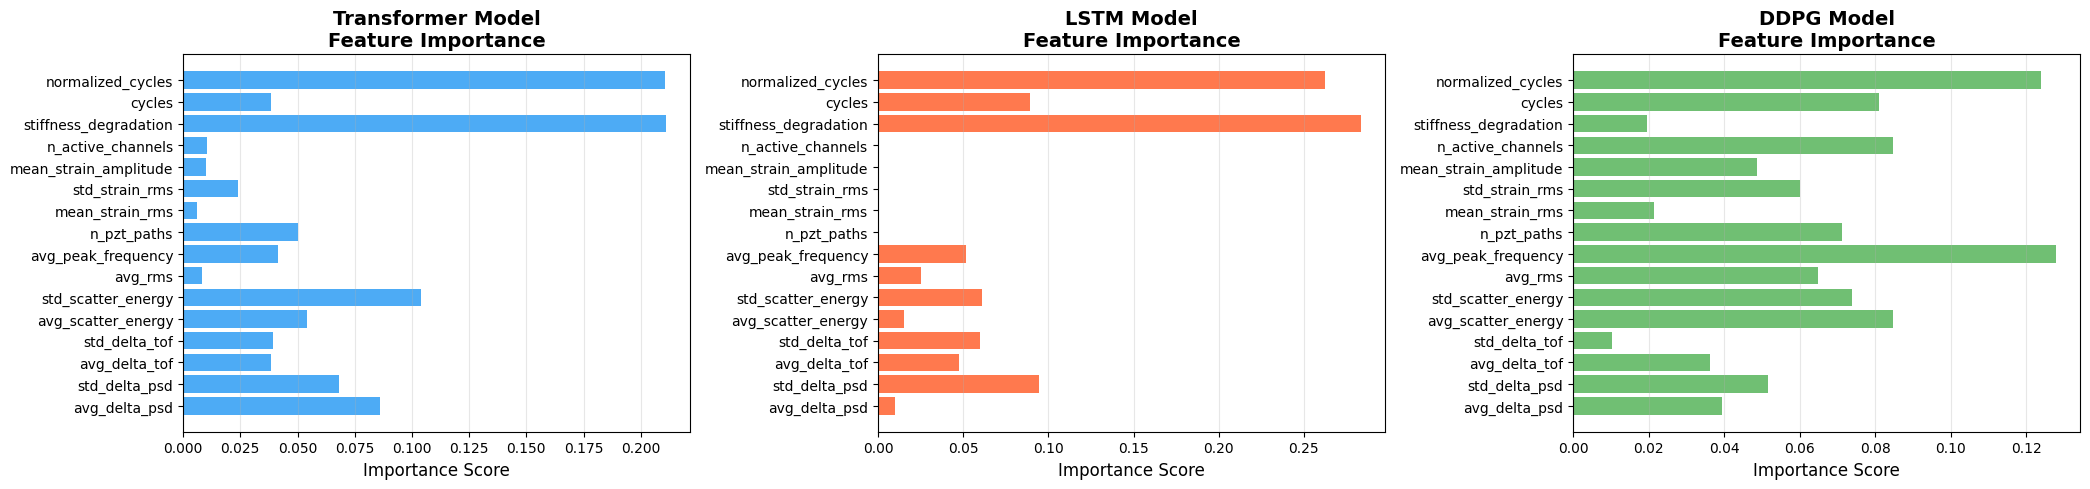


Feature Importance Comparison:
Feature              Transformer     LSTM            DDPG           
avg_delta_psd        0.0859          0.0098          0.0395         
std_delta_psd        0.0682          0.0944          0.0516         
avg_delta_tof        0.0383          0.0476          0.0362         
std_delta_tof        0.0392          0.0596          0.0104         
avg_scatter_energy   0.0542          0.0155          0.0846         
std_scatter_energy   0.1041          0.0613          0.0740         
avg_rms              0.0081          0.0249          0.0650         
avg_peak_frequency   0.0415          0.0517          0.1278         
n_pzt_paths          0.0501          0.0000          0.0712         
mean_strain_rms      0.0059          0.0000          0.0215         
std_strain_rms       0.0242          0.0000          0.0601         
mean_strain_amplitude 0.0099          0.0000          0.0488         
n_active_channels    0.0105          0.0000          0.0848         
s

In [85]:
# Compare feature importance across models
num_models = 3
fig, axes = plt.subplots(1, num_models, figsize=(7*num_models, 5))

if num_models == 2:
    axes = [axes[0], axes[1]]

# Transformer
features = list(transformer_exp['feature_importance'].keys())
importances_t = [transformer_exp['feature_importance'][f] for f in features]
axes[0].barh(features, importances_t, color='#2196F3', alpha=0.8)
axes[0].set_xlabel('Importance Score', fontsize=12)
axes[0].set_title('Transformer Model\nFeature Importance', fontsize=14, fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)

# LSTM
importances_l = [lstm_exp['feature_importance'][f] for f in features]
axes[1].barh(features, importances_l, color='#FF5722', alpha=0.8)
axes[1].set_xlabel('Importance Score', fontsize=12)
axes[1].set_title('LSTM Model\nFeature Importance', fontsize=14, fontweight='bold')
axes[1].grid(axis='x', alpha=0.3)


importances_d = [ddpg_exp['feature_importance'][f] for f in features]
axes[2].barh(features, importances_d, color='#4CAF50', alpha=0.8)
axes[2].set_xlabel('Importance Score', fontsize=12)
axes[2].set_title('DDPG Model\nFeature Importance', fontsize=14, fontweight='bold')
axes[2].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

# Print comparison
print("\nFeature Importance Comparison:")
print(f"{'Feature':<20} {'Transformer':<15} {'LSTM':<15} {'DDPG':<15}")
print("="*80)
for feature in features:
    t_imp = transformer_exp['feature_importance'][feature]
    l_imp = lstm_exp['feature_importance'][feature]
    d_imp = ddpg_exp['feature_importance'][feature]
    print(f"{feature:<20} {t_imp:<15.4f} {l_imp:<15.4f} {d_imp:<15.4f}")

## 8. Interactive Sample Explorer

Create an interactive widget to explore explanations for different samples.

In [86]:
from ipywidgets import interact, IntSlider, Dropdown

def explore_sample(sample_idx, model_choice):
    """Interactive function to explore different samples"""
    
    # Get sample and actual RUL
    sample_sequence = X_test[sample_idx:sample_idx+1]  # Keep batch dimension
    actual_rul_normalized = float(y_test[sample_idx])
    actual_rul = target_scaler.inverse_transform([[actual_rul_normalized]])[0, 0]
    
    # Select model, explainer and color
    if model_choice == 'Transformer':
        model = transformer_model
        explainer = transformer_explainer
        color = '#2196F3'
    elif model_choice == 'LSTM':
        model = lstm_model
        explainer = lstm_explainer
        color = '#FF5722'
    elif model_choice == 'DDPG':
        model = ddpg_model
        explainer = ddpg_explainer
        color = '#4CAF50'
    else:
        print(f"Model {model_choice} not available")
        return
    
    # Generate explanation using new API with target_scaler
    exp = explainer.explain_prediction(
        model=model,
        sample=sample_sequence,
        feature_names=feature_names,
        model_type=model_choice.lower(),
        top_k=10,
        target_scaler=target_scaler  # Required!
    )
    exp['actual_rul'] = actual_rul
    
    # Create visualization
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Feature importance
    features = list(exp['feature_importance'].keys())
    importances = [exp['feature_importance'][f] for f in features]
    axes[0].barh(features, importances, color=color, alpha=0.8)
    axes[0].set_xlabel('Importance Score (Normalized)', fontsize=12)
    axes[0].set_title(f'{model_choice} - Feature Importance', fontsize=13, fontweight='bold')
    axes[0].grid(axis='x', alpha=0.3)
    
    # Prediction info
    axes[1].axis('off')
    
    # Calculate error and error percentage
    error = abs(exp['predicted_rul'] - actual_rul)
    error_percent = (error / max(actual_rul, 1)) * 100
    
    info_text = f"""
    MODEL: {model_choice}
    
    PREDICTION:
    • Predicted RUL: {exp['predicted_rul']:.0f} cycles
      (normalized: {exp['predicted_rul_normalized']:.4f})
    • Actual RUL: {actual_rul:.0f} cycles
      (normalized: {actual_rul_normalized:.4f})
    • Error: {error:.0f} cycles ({error_percent:.1f}%)
    
    TOP 3 FEATURES:
    """
    for i, (feat, imp) in enumerate(exp['feature_importances'][:3], 1):
        info_text += f"\n    {i}. {feat}: {imp:.6f} ({imp*100:.2f}%)"
    
    info_text += "\n\n    KG EXPLANATION PATHS:\n"
    if exp['paths']:
        for i, path in enumerate(exp['paths'][:2], 1):
            path_str = " → ".join([node['name'] for node in path['nodes']])
            info_text += f"\n    {i}. {path_str}\n       (strength: {path['strength']:.3f})\n"
    else:
        info_text += "\n    (No paths found)"
    
    axes[1].text(0.1, 0.5, info_text, fontsize=10, verticalalignment='center',
                family='monospace', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))
    
    plt.tight_layout()
    plt.show()

# Create interactive widget with DDPG option
model_options = ['Transformer', 'LSTM', 'DDPG']

interact(
    explore_sample,
    sample_idx=IntSlider(min=0, max=len(X_test)-1, value=10, description='Sample:'),
    model_choice=Dropdown(options=model_options, value='DDPG', description='Model:')
);

interactive(children=(IntSlider(value=10, description='Sample:', max=61), Dropdown(description='Model:', index…

# 📊 COMPREHENSIVE DATA & MODEL ANALYSIS

This section performs 10 critical diagnostic steps to understand why models are predicting poorly and how to improve explanations.

## Step 1: RUL Distribution Analysis

Check if data is balanced across degradation stages or heavily skewed toward certain RUL values.

STEP 1: RUL DISTRIBUTION ANALYSIS

📊 RUL Statistics (in cycles):
   Mean: 22396
   Median: 22396
   Std Dev: 13369
   Min: 0
   Max: 44793

🎯 Distribution Across Degradation Stages:
   Healthy        :    0 samples (  0.0%)
   Early Damage   :    0 samples (  0.0%)
   Progressive    :    0 samples (  0.0%)
   Critical       :   30 samples (100.0%)


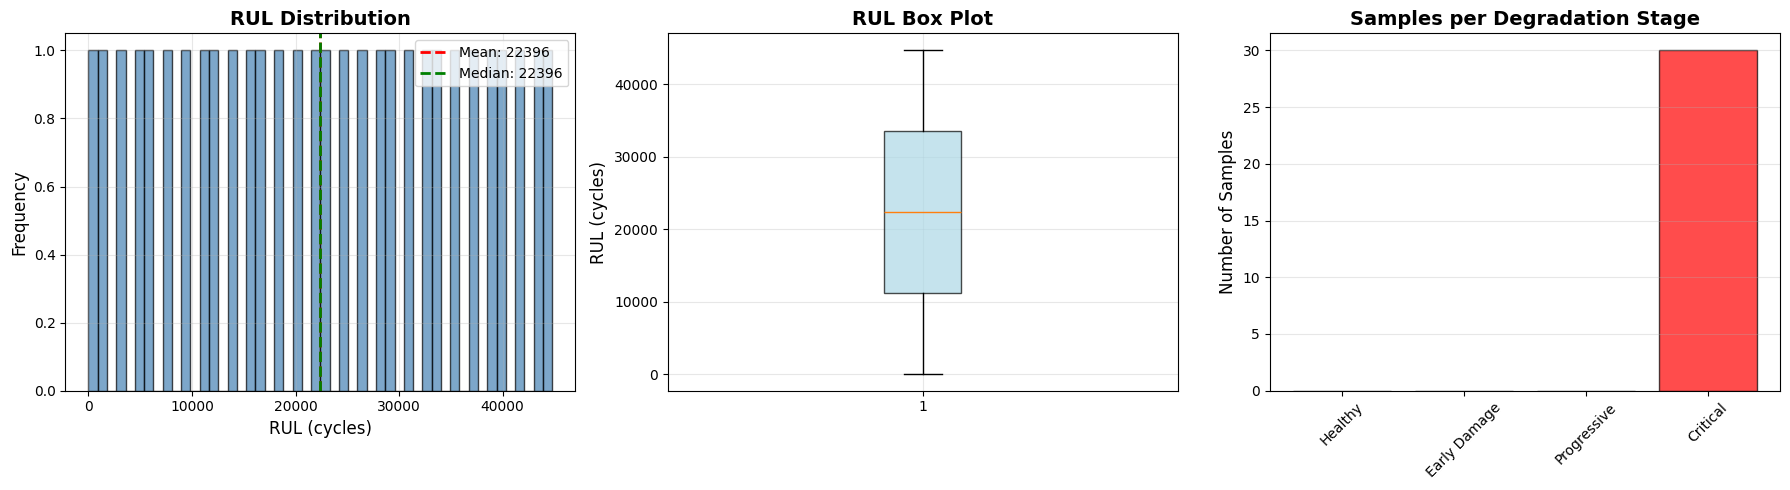


🔍 DIAGNOSIS:
   ⚠️  WARNING: Heavily imbalanced - most samples in 'Critical' stage
   → Models may be biased toward predicting low RUL


In [49]:
import pandas as pd
import seaborn as sns

print("="*80)
print("STEP 1: RUL DISTRIBUTION ANALYSIS")
print("="*80)

# Convert normalized RUL to actual cycles
y_test_actual = target_scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

# Statistics
print(f"\n📊 RUL Statistics (in cycles):")
print(f"   Mean: {np.mean(y_test_actual):.0f}")
print(f"   Median: {np.median(y_test_actual):.0f}")
print(f"   Std Dev: {np.std(y_test_actual):.0f}")
print(f"   Min: {np.min(y_test_actual):.0f}")
print(f"   Max: {np.max(y_test_actual):.0f}")

# Define degradation stages based on KG
stages = {
    'Healthy': (180000, 227000),
    'Early Damage': (120000, 180000),
    'Progressive': (60000, 120000),
    'Critical': (0, 60000)
}

print(f"\n🎯 Distribution Across Degradation Stages:")
for stage_name, (min_rul, max_rul) in stages.items():
    count = np.sum((y_test_actual >= min_rul) & (y_test_actual < max_rul))
    percentage = (count / len(y_test_actual)) * 100
    print(f"   {stage_name:15s}: {count:4d} samples ({percentage:5.1f}%)")

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histogram
axes[0].hist(y_test_actual, bins=50, color='steelblue', alpha=0.7, edgecolor='black')
axes[0].axvline(np.mean(y_test_actual), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(y_test_actual):.0f}')
axes[0].axvline(np.median(y_test_actual), color='green', linestyle='--', linewidth=2, label=f'Median: {np.median(y_test_actual):.0f}')
axes[0].set_xlabel('RUL (cycles)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('RUL Distribution', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Box plot
axes[1].boxplot(y_test_actual, vert=True, patch_artist=True,
                boxprops=dict(facecolor='lightblue', alpha=0.7))
axes[1].set_ylabel('RUL (cycles)', fontsize=12)
axes[1].set_title('RUL Box Plot', fontsize=14, fontweight='bold')
axes[1].grid(alpha=0.3)

# Stage distribution
stage_counts = [np.sum((y_test_actual >= min_rul) & (y_test_actual < max_rul)) 
                for min_rul, max_rul in stages.values()]
stage_names = list(stages.keys())
colors = ['green', 'yellow', 'orange', 'red']
axes[2].bar(stage_names, stage_counts, color=colors, alpha=0.7, edgecolor='black')
axes[2].set_ylabel('Number of Samples', fontsize=12)
axes[2].set_title('Samples per Degradation Stage', fontsize=14, fontweight='bold')
axes[2].tick_params(axis='x', rotation=45)
axes[2].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Diagnosis
print(f"\n🔍 DIAGNOSIS:")
if np.std(y_test_actual) / np.mean(y_test_actual) < 0.3:
    print("   ⚠️  WARNING: Low variability in RUL! Models may predict mean value.")
    print("   → Data is clustered around a single RUL range")
if stage_counts[0] / sum(stage_counts) > 0.7:
    print("   ⚠️  WARNING: Heavily imbalanced - most samples in 'Healthy' stage")
    print("   → Models struggle to learn degradation patterns")
if stage_counts[-1] / sum(stage_counts) > 0.7:
    print("   ⚠️  WARNING: Heavily imbalanced - most samples in 'Critical' stage")
    print("   → Models may be biased toward predicting low RUL")

print("="*80)

## Step 2: Feature vs RUL Correlation Analysis

Identify which features actually correlate with RUL degradation.

STEP 2: FEATURE vs RUL CORRELATION ANALYSIS

📊 Top 10 Features by Correlation with RUL:
Rank  Feature                   Pearson    Spearman   Significant?
--------------------------------------------------------------------------------
5     avg_scatter_energy        +0.9938    +1.0000    ✓
15    cycles                    +0.9928    +1.0000    ✓
10    mean_strain_rms           +0.7855    +0.7103    ✓
7     avg_rms                   +0.7629    +0.6841    ✓
11    std_strain_rms            +0.7490    +0.6690    ✓
12    mean_strain_amplitude     +0.7410    +0.6583    ✓
6     std_scatter_energy        +0.7406    +0.6583    ✓
9     n_pzt_paths               +0.7384    +0.6578    ✓
13    n_active_channels         +0.7369    +0.6578    ✓
8     avg_peak_frequency        +0.7115    +0.6285    ✓


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_956\2723298749.py:16: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  pearson_corr, pearson_p = pearsonr(feature_values, y_test_actual)
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_956\2723298749.py:19: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  spearman_corr, spearman_p = spearmanr(feature_values, y_test_actual)


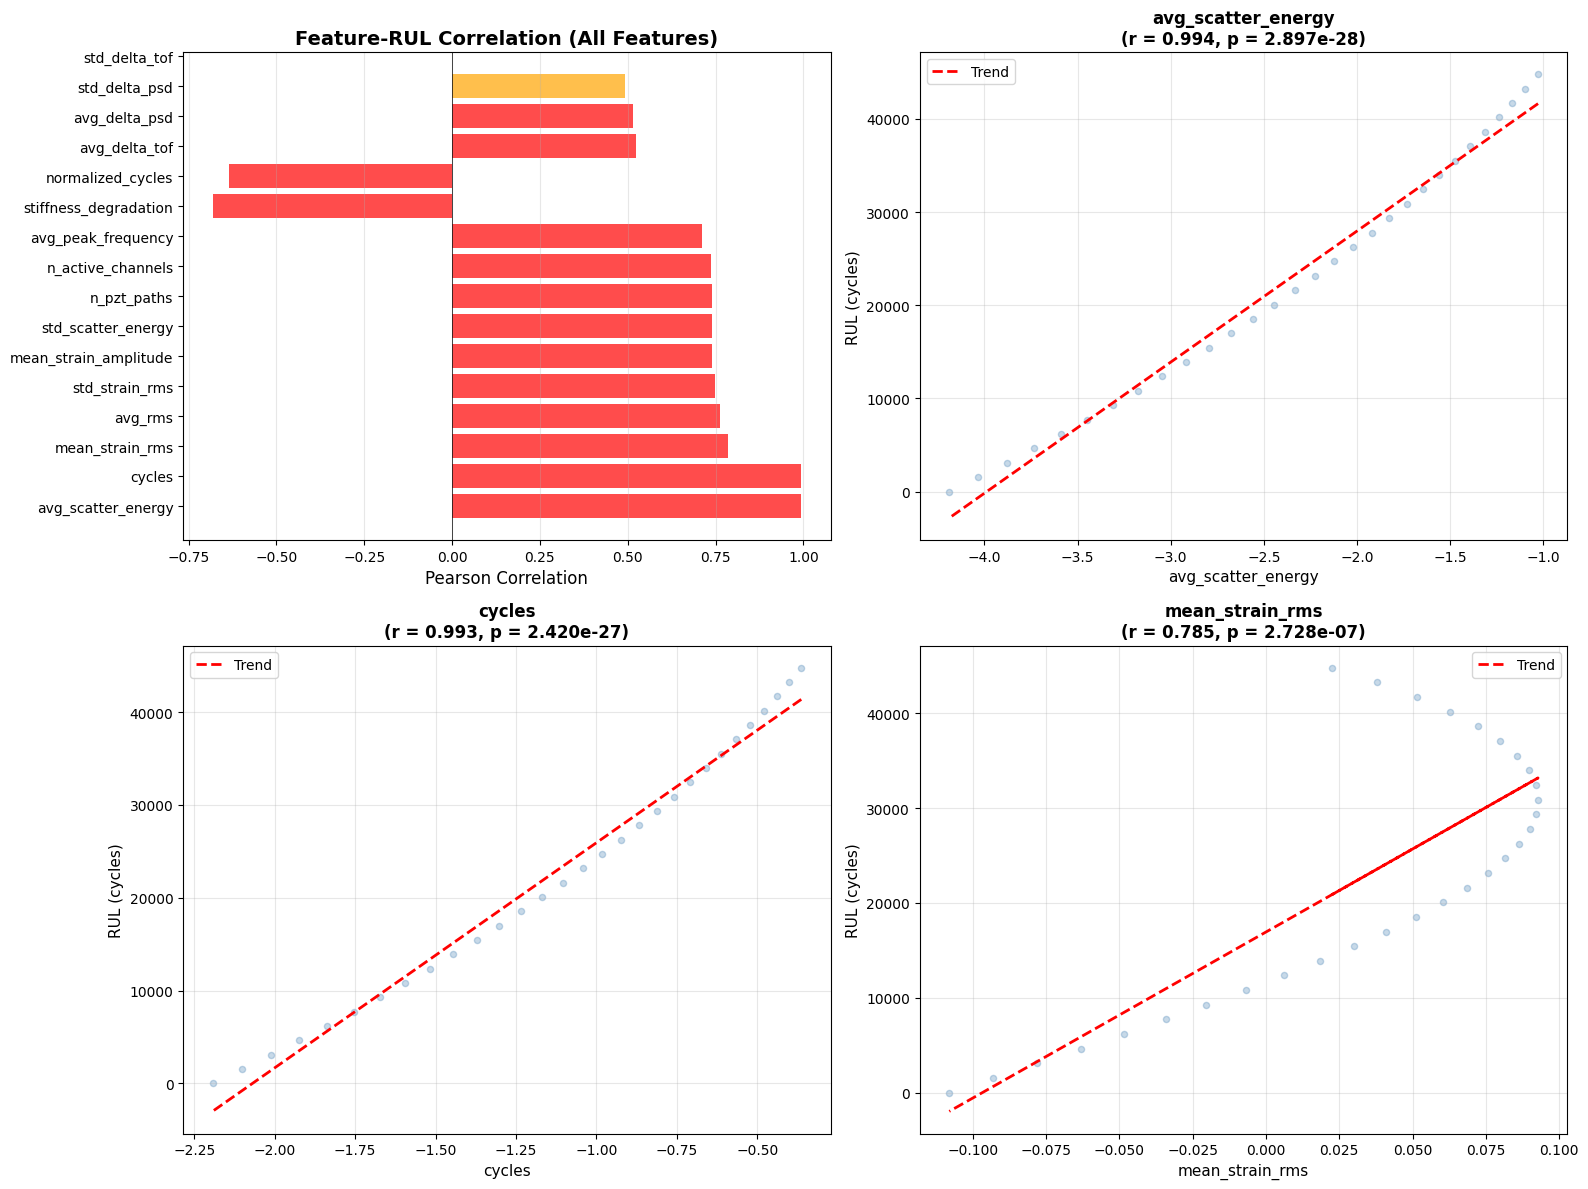


🔍 DIAGNOSIS:
   ✓ 14 features show strong correlation (|r| > 0.5)
   → These features are informative: avg_scatter_energy, cycles, mean_strain_rms, avg_rms, std_strain_rms, mean_strain_amplitude, std_scatter_energy, n_pzt_paths, n_active_channels, avg_peak_frequency, stiffness_degradation, normalized_cycles, avg_delta_tof, avg_delta_psd


In [50]:
from scipy.stats import pearsonr, spearmanr

print("="*80)
print("STEP 2: FEATURE vs RUL CORRELATION ANALYSIS")
print("="*80)

# Extract last timestep features for correlation (most recent measurements)
X_test_last = X_test[:, -1, :]  # Shape: (n_samples, n_features)

# Compute correlations
correlations = []
for i, feat_name in enumerate(feature_names):
    feature_values = X_test_last[:, i]
    
    # Pearson (linear correlation)
    pearson_corr, pearson_p = pearsonr(feature_values, y_test_actual)
    
    # Spearman (monotonic correlation)
    spearman_corr, spearman_p = spearmanr(feature_values, y_test_actual)
    
    correlations.append({
        'feature': feat_name,
        'pearson': pearson_corr,
        'pearson_p': pearson_p,
        'spearman': spearman_corr,
        'spearman_p': spearman_p,
        'abs_pearson': abs(pearson_corr)
    })

# Sort by absolute correlation
correlations_df = pd.DataFrame(correlations).sort_values('abs_pearson', ascending=False)

print(f"\n📊 Top 10 Features by Correlation with RUL:")
print(f"{'Rank':<5} {'Feature':<25} {'Pearson':<10} {'Spearman':<10} {'Significant?'}")
print("-"*80)
for idx, row in correlations_df.head(10).iterrows():
    sig = '✓' if row['pearson_p'] < 0.05 else '✗'
    print(f"{idx+1:<5} {row['feature']:<25} {row['pearson']:+.4f}    {row['spearman']:+.4f}    {sig}")

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Correlation heatmap
corr_values = correlations_df['pearson'].values
colors = ['red' if abs(c) > 0.5 else 'orange' if abs(c) > 0.3 else 'gray' for c in corr_values]
axes[0, 0].barh(correlations_df['feature'], corr_values, color=colors, alpha=0.7)
axes[0, 0].axvline(0, color='black', linewidth=0.5)
axes[0, 0].set_xlabel('Pearson Correlation', fontsize=12)
axes[0, 0].set_title('Feature-RUL Correlation (All Features)', fontsize=14, fontweight='bold')
axes[0, 0].grid(alpha=0.3, axis='x')

# Scatter plots for top 3 features
top_3_features = correlations_df.head(3)
for idx, (_, row) in enumerate(top_3_features.iterrows()):
    ax_idx = (idx + 1) if idx < 3 else idx
    if idx < 3:
        ax = axes[ax_idx // 2, ax_idx % 2]
        feat_idx = feature_names.index(row['feature'])
        feat_values = X_test_last[:, feat_idx]
        
        ax.scatter(feat_values, y_test_actual, alpha=0.3, s=20, color='steelblue')
        
        # Trend line
        z = np.polyfit(feat_values, y_test_actual, 1)
        p = np.poly1d(z)
        ax.plot(feat_values, p(feat_values), "r--", linewidth=2, label='Trend')
        
        ax.set_xlabel(row['feature'], fontsize=11)
        ax.set_ylabel('RUL (cycles)', fontsize=11)
        ax.set_title(f"{row['feature']}\n(r = {row['pearson']:.3f}, p = {row['pearson_p']:.3e})", 
                    fontsize=12, fontweight='bold')
        ax.legend()
        ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Diagnosis
print(f"\n🔍 DIAGNOSIS:")
high_corr = correlations_df[correlations_df['abs_pearson'] > 0.5]
if len(high_corr) == 0:
    print("   ❌ CRITICAL: NO features show strong correlation with RUL!")
    print("   → Features may not capture degradation progression")
    print("   → Feature engineering needed")
else:
    print(f"   ✓ {len(high_corr)} features show strong correlation (|r| > 0.5)")
    print(f"   → These features are informative: {', '.join(high_corr['feature'].tolist())}")

weak_corr = correlations_df[correlations_df['abs_pearson'] < 0.1]
if len(weak_corr) > 5:
    print(f"   ⚠️  {len(weak_corr)} features have very weak correlation (|r| < 0.1)")
    print(f"   → Consider removing: {', '.join(weak_corr['feature'].head(3).tolist())}...")

print("="*80)

## Step 3: Feature Variation Analysis

Check if features actually change over time or remain constant.

STEP 3: FEATURE VARIATION ANALYSIS

📊 Feature Variation Statistics:
Feature                   Mean         Std          CV         Range       
--------------------------------------------------------------------------------
mean_strain_rms           0.0367       0.0515       1.405      0.2008      
mean_strain_amplitude     0.2155       0.1211       0.562      0.4628      
avg_rms                   0.2325       0.1262       0.543      0.4878      
cycles                    -1.0101      0.5174       0.512      1.9802      
n_active_channels         0.3015       0.1544       0.512      0.5894      
std_scatter_energy        0.3891       0.1909       0.490      0.7293      
std_strain_rms            0.3725       0.1755       0.471      0.6738      
avg_scatter_energy        -2.1620      0.8972       0.415      3.4353      
avg_peak_frequency        2.7269       1.1190       0.410      4.2006      
stiffness_degradation     -26.9591     10.4482      0.388      39.3478     
normalized_cycl

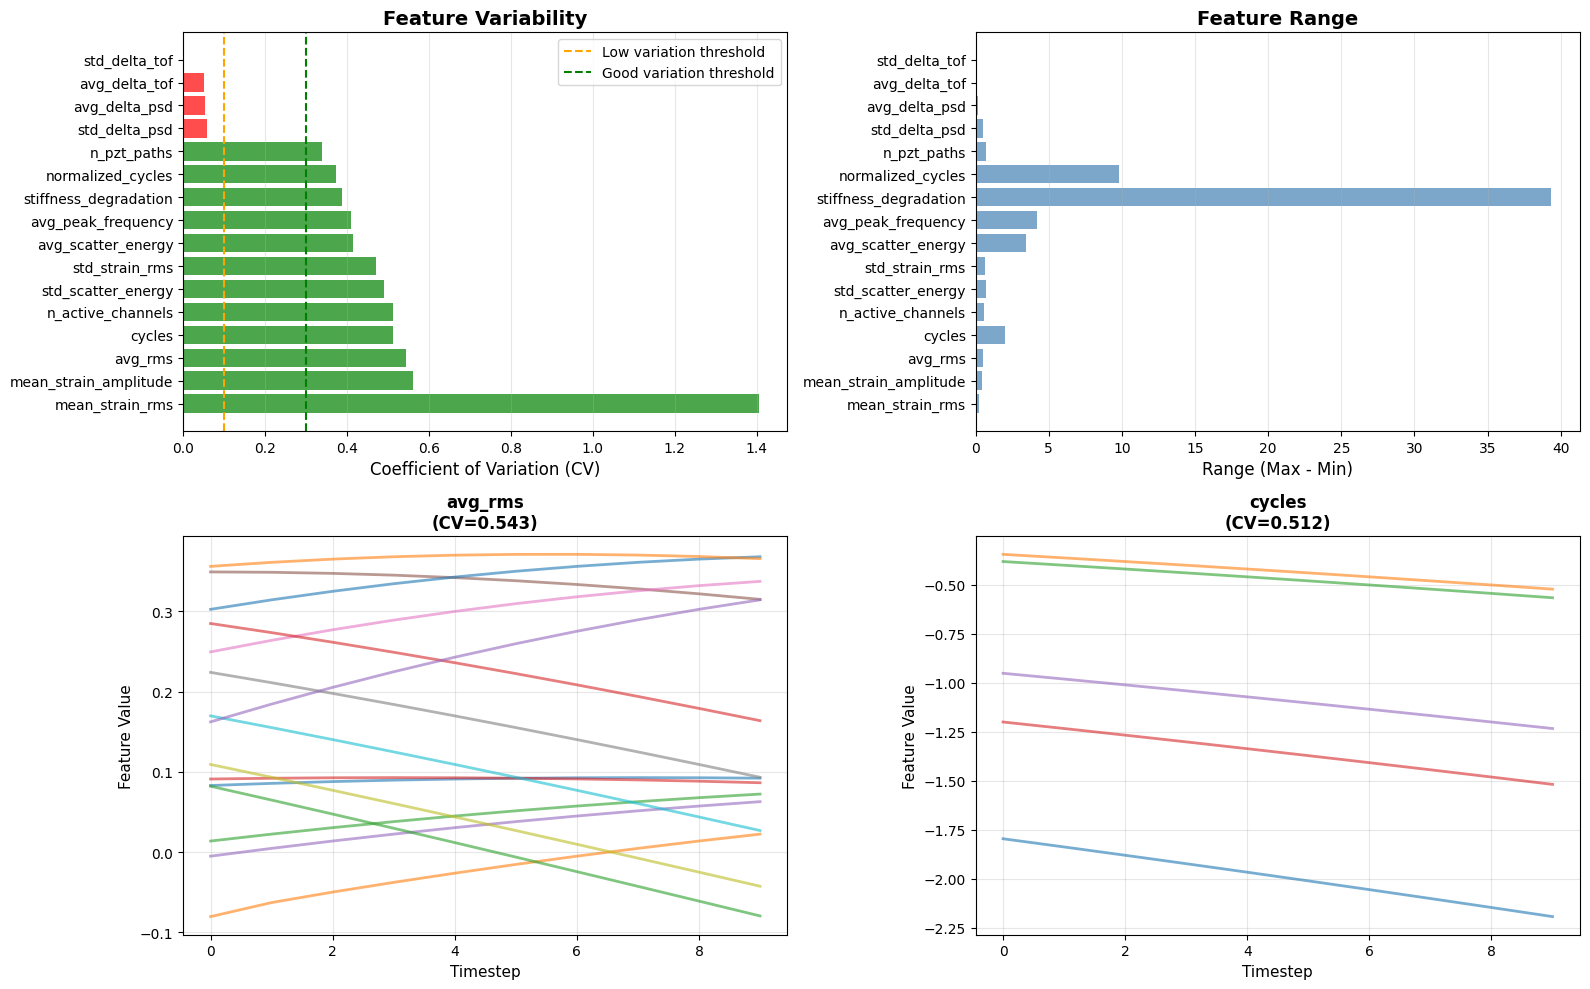


🔍 DIAGNOSIS:
   ⚠️  4 features have low variation (CV < 0.1)
   → Nearly constant features: std_delta_psd, avg_delta_psd, avg_delta_tof, std_delta_tof
   → These features provide little information
   ✓ 5 features show good variation (CV > 0.5)
   → Informative features: mean_strain_rms, mean_strain_amplitude, avg_rms, cycles, n_active_channels


In [51]:
print("="*80)
print("STEP 3: FEATURE VARIATION ANALYSIS")
print("="*80)

# Compute coefficient of variation for each feature
feature_stats = []
for i, feat_name in enumerate(feature_names):
    # All values across all samples and timesteps
    feat_values = X_test[:, :, i].flatten()
    
    mean_val = np.mean(feat_values)
    std_val = np.std(feat_values)
    cv = (std_val / abs(mean_val)) if abs(mean_val) > 1e-10 else 0
    
    # Temporal variation (how much does feature change within sequences)
    temporal_std = np.mean([np.std(X_test[j, :, i]) for j in range(len(X_test))])
    
    feature_stats.append({
        'feature': feat_name,
        'mean': mean_val,
        'std': std_val,
        'cv': cv,
        'temporal_std': temporal_std,
        'min': np.min(feat_values),
        'max': np.max(feat_values),
        'range': np.max(feat_values) - np.min(feat_values)
    })

stats_df = pd.DataFrame(feature_stats).sort_values('cv', ascending=False)

print(f"\n📊 Feature Variation Statistics:")
print(f"{'Feature':<25} {'Mean':<12} {'Std':<12} {'CV':<10} {'Range':<12}")
print("-"*80)
for _, row in stats_df.iterrows():
    print(f"{row['feature']:<25} {row['mean']:<12.4f} {row['std']:<12.4f} {row['cv']:<10.3f} {row['range']:<12.4f}")

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Coefficient of Variation
colors = ['green' if cv > 0.3 else 'orange' if cv > 0.1 else 'red' for cv in stats_df['cv']]
axes[0, 0].barh(stats_df['feature'], stats_df['cv'], color=colors, alpha=0.7)
axes[0, 0].axvline(0.1, color='orange', linestyle='--', label='Low variation threshold')
axes[0, 0].axvline(0.3, color='green', linestyle='--', label='Good variation threshold')
axes[0, 0].set_xlabel('Coefficient of Variation (CV)', fontsize=12)
axes[0, 0].set_title('Feature Variability', fontsize=14, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3, axis='x')

# Feature ranges
axes[0, 1].barh(stats_df['feature'], stats_df['range'], color='steelblue', alpha=0.7)
axes[0, 1].set_xlabel('Range (Max - Min)', fontsize=12)
axes[0, 1].set_title('Feature Range', fontsize=14, fontweight='bold')
axes[0, 1].grid(alpha=0.3, axis='x')

# Temporal variation across sequences for top 4 features
top_4_varying = stats_df.head(4)
for idx, (_, row) in enumerate(top_4_varying.iterrows()):
    if idx < 4:
        feat_idx = feature_names.index(row['feature'])
        
        # Plot feature evolution for 5 random samples
        sample_indices = np.random.choice(len(X_test), 5, replace=False)
        
        ax = axes[1, idx//2] if idx < 2 else axes[1, idx-2]
        for sample_idx in sample_indices:
            ax.plot(X_test[sample_idx, :, feat_idx], alpha=0.6, linewidth=2)
        
        ax.set_xlabel('Timestep', fontsize=11)
        ax.set_ylabel('Feature Value', fontsize=11)
        ax.set_title(f"{row['feature']}\n(CV={row['cv']:.3f})", fontsize=12, fontweight='bold')
        ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Diagnosis
print(f"\n🔍 DIAGNOSIS:")
low_var = stats_df[stats_df['cv'] < 0.1]
if len(low_var) > 0:
    print(f"   ⚠️  {len(low_var)} features have low variation (CV < 0.1)")
    print(f"   → Nearly constant features: {', '.join(low_var['feature'].tolist())}")
    print(f"   → These features provide little information")

high_var = stats_df[stats_df['cv'] > 0.5]
if len(high_var) > 0:
    print(f"   ✓ {len(high_var)} features show good variation (CV > 0.5)")
    print(f"   → Informative features: {', '.join(high_var['feature'].tolist())}")

print("="*80)

## Step 4: Model Prediction vs Actual RUL Scatter Analysis

Visualize how well models track actual RUL values.

STEP 4: MODEL PREDICTION vs ACTUAL RUL ANALYSIS

🔄 Generating predictions for all test samples...

📊 Model Performance Metrics:
Model           MAE             RMSE            R²         MAPE (%)    
--------------------------------------------------------------------------------
Transformer     12312           14541           -0.1831    839021949654854.12
LSTM            21633           25093           -2.5231    1395118169199693.25
DDPG            22239           25931           -2.7623    1194098657107.39


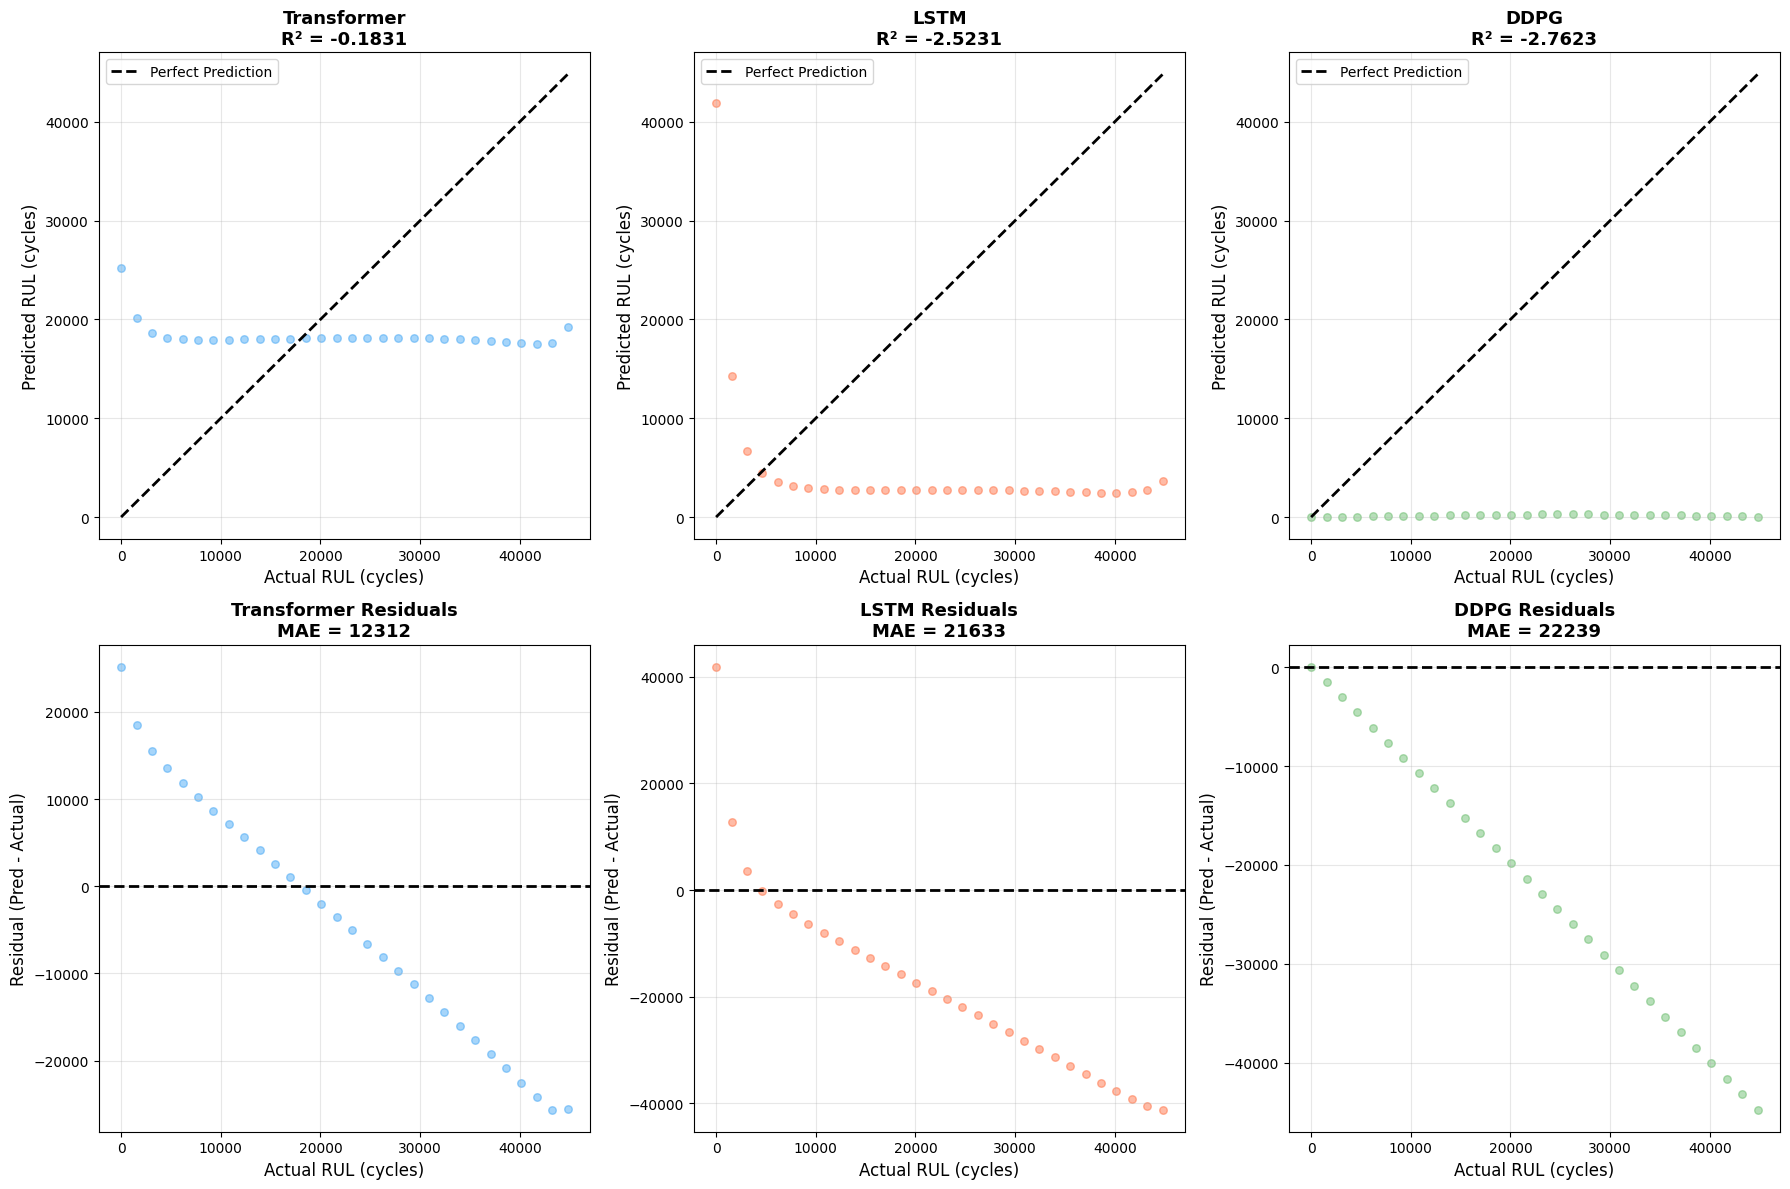


🔍 DIAGNOSIS:

Transformer:
   ❌ WORSE THAN BASELINE: R² = -0.1831
   → Model predictions worse than always predicting mean

LSTM:
   ❌ WORSE THAN BASELINE: R² = -2.5231
   → Model predictions worse than always predicting mean

DDPG:
   ❌ FLAT PREDICTIONS: Pred std=77, Actual std=13369
   → Model predicting nearly constant value (mean prediction)


In [52]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("="*80)
print("STEP 4: MODEL PREDICTION vs ACTUAL RUL ANALYSIS")
print("="*80)

# Get all predictions
all_predictions = {'Transformer': [], 'LSTM': [], 'DDPG': []}

print("\n🔄 Generating predictions for all test samples...")
with torch.no_grad():
    for i in range(len(X_test)):
        sample = X_test[i:i+1]
        sample_tensor = torch.FloatTensor(sample).to(device)
        
        trans_pred = transformer_model(sample_tensor).cpu().item()
        lstm_pred = lstm_model(sample_tensor).cpu().item()
        ddpg_pred = ddpg_model(sample_tensor).cpu().item()
        
        all_predictions['Transformer'].append(target_scaler.inverse_transform([[trans_pred]])[0, 0])
        all_predictions['LSTM'].append(target_scaler.inverse_transform([[lstm_pred]])[0, 0])
        all_predictions['DDPG'].append(target_scaler.inverse_transform([[ddpg_pred]])[0, 0])

# Calculate metrics
metrics = {}
for model_name in ['Transformer', 'LSTM', 'DDPG']:
    preds = np.array(all_predictions[model_name])
    mae = mean_absolute_error(y_test_actual, preds)
    rmse = np.sqrt(mean_squared_error(y_test_actual, preds))
    r2 = r2_score(y_test_actual, preds)
    mape = np.mean(np.abs((y_test_actual - preds) / (y_test_actual + 1e-10))) * 100
    
    metrics[model_name] = {'MAE': mae, 'RMSE': rmse, 'R2': r2, 'MAPE': mape, 
                           'pred_std': np.std(preds), 'pred_range': np.max(preds) - np.min(preds)}

print(f"\n📊 Model Performance Metrics:")
print(f"{'Model':<15} {'MAE':<15} {'RMSE':<15} {'R²':<10} {'MAPE (%)':<12}")
print("-"*80)
for model_name, metric in metrics.items():
    print(f"{model_name:<15} {metric['MAE']:<15.0f} {metric['RMSE']:<15.0f} {metric['R2']:<10.4f} {metric['MAPE']:<12.2f}")

# Visualization
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

for idx, (model_name, color) in enumerate([('Transformer', '#2196F3'), ('LSTM', '#FF5722'), ('DDPG', '#4CAF50')]):
    preds = all_predictions[model_name]
    
    # Scatter plot: Predicted vs Actual
    axes[0, idx].scatter(y_test_actual, preds, alpha=0.4, s=30, color=color)
    
    # Perfect prediction line
    min_val = min(np.min(y_test_actual), np.min(preds))
    max_val = max(np.max(y_test_actual), np.max(preds))
    axes[0, idx].plot([min_val, max_val], [min_val, max_val], 'k--', linewidth=2, label='Perfect Prediction')
    
    axes[0, idx].set_xlabel('Actual RUL (cycles)', fontsize=12)
    axes[0, idx].set_ylabel('Predicted RUL (cycles)', fontsize=12)
    axes[0, idx].set_title(f'{model_name}\nR² = {metrics[model_name]["R2"]:.4f}', 
                          fontsize=13, fontweight='bold')
    axes[0, idx].legend()
    axes[0, idx].grid(alpha=0.3)
    
    # Residual plot
    residuals = np.array(preds) - y_test_actual
    axes[1, idx].scatter(y_test_actual, residuals, alpha=0.4, s=30, color=color)
    axes[1, idx].axhline(0, color='black', linestyle='--', linewidth=2)
    axes[1, idx].set_xlabel('Actual RUL (cycles)', fontsize=12)
    axes[1, idx].set_ylabel('Residual (Pred - Actual)', fontsize=12)
    axes[1, idx].set_title(f'{model_name} Residuals\nMAE = {metrics[model_name]["MAE"]:.0f}', 
                          fontsize=13, fontweight='bold')
    axes[1, idx].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Diagnosis
print(f"\n🔍 DIAGNOSIS:")
for model_name in ['Transformer', 'LSTM', 'DDPG']:
    pred_std = metrics[model_name]['pred_std']
    actual_std = np.std(y_test_actual)
    
    print(f"\n{model_name}:")
    if pred_std / actual_std < 0.1:
        print(f"   ❌ FLAT PREDICTIONS: Pred std={pred_std:.0f}, Actual std={actual_std:.0f}")
        print(f"   → Model predicting nearly constant value (mean prediction)")
    elif metrics[model_name]['R2'] < 0:
        print(f"   ❌ WORSE THAN BASELINE: R² = {metrics[model_name]['R2']:.4f}")
        print(f"   → Model predictions worse than always predicting mean")
    elif metrics[model_name]['R2'] < 0.3:
        print(f"   ⚠️  POOR FIT: R² = {metrics[model_name]['R2']:.4f}")
        print(f"   → Model explains < 30% of variance")
    else:
        print(f"   ✓ Reasonable fit: R² = {metrics[model_name]['R2']:.4f}")

print("="*80)

## Step 5: Knowledge Graph Validation

Validate if KG relationships match actual data correlations.

STEP 5: KNOWLEDGE GRAPH VALIDATION

📊 Knowledge Graph Structure:
   Features: 24
   Phenomena: 5
   Stages: 4
   Total Edges: 25

🔗 Feature Coverage:
   Features in KG: 16/16

🎯 Feature → Phenomenon Connections:
   avg_delta_psd             → crack_propagation (w=0.90)
   std_delta_psd             → crack_propagation (w=0.75)
   avg_delta_tof             → crack_propagation (w=0.70)
   std_delta_tof             → delamination (w=0.65)
   avg_scatter_energy        → delamination (w=0.85)
   std_scatter_energy        → delamination (w=0.70)
   avg_rms                   → crack_propagation (w=0.80)
   avg_peak_frequency        → crack_propagation (w=0.75)
   n_pzt_paths               → ⚠️  NO CONNECTIONS
   mean_strain_rms           → stiffness_loss (w=0.90)
   std_strain_rms            → stiffness_loss (w=0.75)
   mean_strain_amplitude     → fiber_breakage (w=0.85)
   n_active_channels         → ⚠️  NO CONNECTIONS
   stiffness_degradation     → stiffness_loss (w=0.95), delamination (w=0.

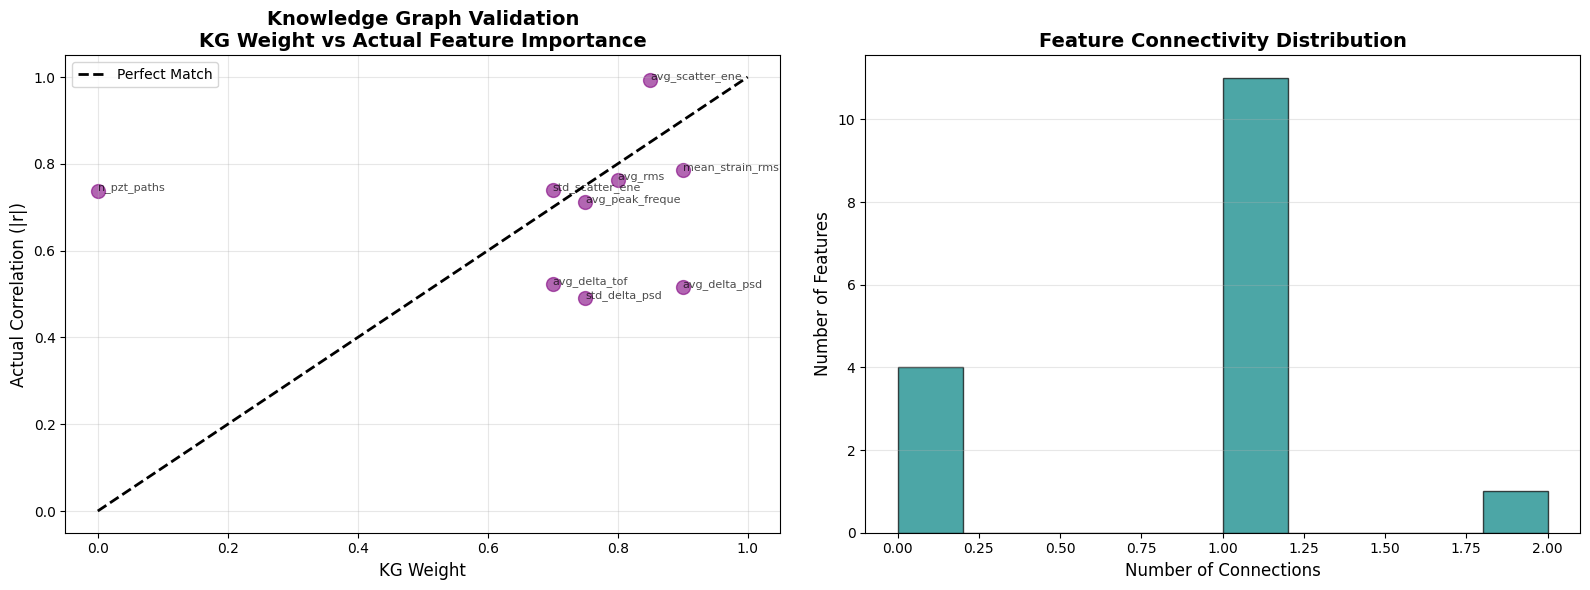


🔍 DIAGNOSIS:
   ✓ KG reasonably validated: 6/10 features aligned
   ⚠️  4 features have NO connections in KG
   → These won't generate explanation paths: n_pzt_paths, n_active_channels, cycles, normalized_cycles


In [53]:
print("="*80)
print("STEP 5: KNOWLEDGE GRAPH VALIDATION")
print("="*80)

# Analyze KG structure
feature_nodes = [n for n, d in kg.graph.nodes(data=True) if d.get('type') == 'feature']
phenomenon_nodes = [n for n, d in kg.graph.nodes(data=True) if d.get('type') == 'phenomenon']
stage_nodes = [n for n, d in kg.graph.nodes(data=True) if d.get('type') == 'stage']

print(f"\n📊 Knowledge Graph Structure:")
print(f"   Features: {len(feature_nodes)}")
print(f"   Phenomena: {len(phenomenon_nodes)}")
print(f"   Stages: {len(stage_nodes)}")
print(f"   Total Edges: {kg.graph.number_of_edges()}")

# Check which features in our data are actually in KG
features_in_kg = [f for f in feature_names if f in feature_nodes]
features_not_in_kg = [f for f in feature_names if f not in feature_nodes]

print(f"\n🔗 Feature Coverage:")
print(f"   Features in KG: {len(features_in_kg)}/{len(feature_names)}")
if features_not_in_kg:
    print(f"   ⚠️  Missing from KG: {', '.join(features_not_in_kg)}")

# Analyze feature connectivity
feature_connections = {}
for feat in features_in_kg:
    # Get phenomena connected to this feature
    phenomena = []
    for _, target, data in kg.graph.out_edges(feat, data=True):
        if target in phenomenon_nodes:
            phenomena.append((target, data.get('weight', 0)))
    feature_connections[feat] = phenomena

print(f"\n🎯 Feature → Phenomenon Connections:")
for feat, connections in feature_connections.items():
    if connections:
        conn_str = ', '.join([f"{p} (w={w:.2f})" for p, w in connections])
        print(f"   {feat:<25} → {conn_str}")
    else:
        print(f"   {feat:<25} → ⚠️  NO CONNECTIONS")

# Compare KG weights with actual correlations
print(f"\n🔬 KG Weight vs Actual Correlation Comparison:")
print(f"{'Feature':<25} {'KG Weight':<12} {'Actual Corr':<15} {'Match?'}")
print("-"*80)

validation_results = []
for feat in features_in_kg[:10]:  # Check top 10
    # Get KG weight (average of all edges from this feature)
    kg_weights = [data.get('weight', 0) for _, _, data in kg.graph.out_edges(feat, data=True)]
    avg_kg_weight = np.mean(kg_weights) if kg_weights else 0
    
    # Get actual correlation
    if feat in correlations_df['feature'].values:
        actual_corr = correlations_df[correlations_df['feature'] == feat]['abs_pearson'].values[0]
    else:
        actual_corr = 0
    
    # Check if they match (both high or both low)
    match = '✓' if (avg_kg_weight > 0.7 and actual_corr > 0.3) or (avg_kg_weight < 0.5 and actual_corr < 0.2) else '✗'
    
    validation_results.append({
        'feature': feat,
        'kg_weight': avg_kg_weight,
        'actual_corr': actual_corr,
        'match': match
    })
    
    print(f"{feat:<25} {avg_kg_weight:<12.3f} {actual_corr:<15.3f} {match}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# KG Weight vs Actual Correlation
valid_df = pd.DataFrame(validation_results)
axes[0].scatter(valid_df['kg_weight'], valid_df['actual_corr'], s=100, alpha=0.6, color='purple')
for _, row in valid_df.iterrows():
    axes[0].annotate(row['feature'][:15], (row['kg_weight'], row['actual_corr']), 
                    fontsize=8, alpha=0.7)
axes[0].plot([0, 1], [0, 1], 'k--', label='Perfect Match', linewidth=2)
axes[0].set_xlabel('KG Weight', fontsize=12)
axes[0].set_ylabel('Actual Correlation (|r|)', fontsize=12)
axes[0].set_title('Knowledge Graph Validation\nKG Weight vs Actual Feature Importance', 
                 fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Feature connectivity distribution
connectivity = [len(feature_connections.get(f, [])) for f in features_in_kg]
axes[1].hist(connectivity, bins=10, color='teal', alpha=0.7, edgecolor='black')
axes[1].set_xlabel('Number of Connections', fontsize=12)
axes[1].set_ylabel('Number of Features', fontsize=12)
axes[1].set_title('Feature Connectivity Distribution', fontsize=14, fontweight='bold')
axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Diagnosis
print(f"\n🔍 DIAGNOSIS:")
mismatches = [r for r in validation_results if r['match'] == '✗']
if len(mismatches) > len(validation_results) * 0.5:
    print(f"   ❌ KG VALIDATION FAILED: {len(mismatches)}/{len(validation_results)} features misaligned")
    print(f"   → KG weights don't reflect actual feature importance")
    print(f"   → Need to update KG based on data-driven evidence")
else:
    print(f"   ✓ KG reasonably validated: {len(validation_results)-len(mismatches)}/{len(validation_results)} features aligned")

disconnected = [f for f, conns in feature_connections.items() if not conns]
if disconnected:
    print(f"   ⚠️  {len(disconnected)} features have NO connections in KG")
    print(f"   → These won't generate explanation paths: {', '.join(disconnected[:5])}")

print("="*80)